In [ ]:
import os
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
plt.rcParams["font.size"] = 14
pd.options.display.float_format = "{:.3f}".format

In [ ]:
def get_number_of_instructions(circuit_name: str) -> int:
    with open(f"../../data/circuit/{circuit_name}.in") as f:
        lines = f.readlines()
    return sum(bool(line) for line in lines)

In [ ]:
df = pd.read_csv("../../out/table/20250812_all.csv")

In [ ]:
instruction_count = {c: get_number_of_instructions(c) for c in df["circuit"].unique()}
df["instruction_count"] = df["circuit"].map(instruction_count)
df["cbpi"] = df["total code beat"] / df["instruction_count"]
df

,circuit,factory,layer count,allocator,msf coeff,routing_algo,routing_option,total code beat,circuit volume,instruction_count,cbpi
0,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,inner,1,SA,0.001,Double,No_MSF,315,18346,14754,0.021
1,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,inner,1,SA,0.001,Double,No_Top,885,125440,14754,0.060
2,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,inner,1,SA,0.001,Proj,No_Top,855,54588,14754,0.058
3,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,inner,1,SA,0.001,Proj,No_MSF,246,4428,14754,0.017
4,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,inner,1,SA,0.001,Single,No_MSF,318,18630,14754,0.022
...,...,...,...,...,...,...,...,...,...,...,...
18487,result_trotter_4_Heisenberg2D_cylinder_0.5_0.5...,outer,2,naive,0.000,Proj,No_Kink,472,53588,2160,0.219
18488,result_trotter_4_Heisenberg2D_cylinder_0.5_0.5...,outer,2,naive,0.000,Proj,Yes_Kink,494,52910,2160,0.229
18489,result_trotter_4_Heisenberg2D_cylinder_0.5_0.5...,outer,2,random,0.000,Single,Yes_Kink,537,22350,2160,0.249
18490,result_trotter_4_Heisenberg2D_cylinder_0.5_0.5...,outer,2,random,0.000,Proj,No_Kink,487,55960,2160,0.225


In [ ]:
idx = df.groupby(
    ["circuit", "factory", "layer count", "allocator", "routing_algo", "routing_option"]
)["total code beat"].idxmin()
df_best = df.loc[idx]

In [ ]:
df_best

,circuit,factory,layer count,allocator,msf coeff,routing_algo,routing_option,total code beat,circuit volume,instruction_count,cbpi
2216,result_SELECT_100_Heisenberg1D_OBC_1_0_0,inner,1,SA,0.001,Double,No_Kink,8062,355017,13100,0.615
2209,result_SELECT_100_Heisenberg1D_OBC_1_0_0,inner,1,SA,0.001,Double,No_MSF,8061,176904,13100,0.615
2210,result_SELECT_100_Heisenberg1D_OBC_1_0_0,inner,1,SA,0.001,Double,No_Top,8062,195978,13100,0.615
2220,result_SELECT_100_Heisenberg1D_OBC_1_0_0,inner,1,SA,0.001,Double,Yes_Kink,8062,353059,13100,0.615
2243,result_SELECT_100_Heisenberg1D_OBC_1_0_0,inner,1,SA,0.001,Proj,No_Kink,7132,3204558,13100,0.544
...,...,...,...,...,...,...,...,...,...,...,...
2202,result_trotter_4_Heisenberg2D_cylinder_0.5_0.5...,outer,2,random,0.000,Proj,Yes_Kink,496,53792,2160,0.230
2198,result_trotter_4_Heisenberg2D_cylinder_0.5_0.5...,outer,2,random,0.000,Single,No_Kink,537,21928,2160,0.249
2200,result_trotter_4_Heisenberg2D_cylinder_0.5_0.5...,outer,2,random,0.000,Single,No_MSF,536,5746,2160,0.248
2201,result_trotter_4_Heisenberg2D_cylinder_0.5_0.5...,outer,2,random,0.000,Single,No_Top,537,13153,2160,0.249


# CBPI stack

In [ ]:
options: list[tuple[int, str]] = [
    (1, "outer"),
    (1, "inner"),
    (2, "outer"),
    (2, "inner"),
]

routing_algos: list[str] = ["Single", "Double", "Proj"]

breakdown: dict[str, str] = {
    "No_MSF": "Base",
    "No_Top": "Magic",
    "No_Kink": "Path",
    "Yes_Kink": "Kink",
}


def draw(ax: Any, df_ax: pd.Series) -> None:
    bottom = np.zeros(len(routing_algos))
    for label_for_df, label_for_legend in breakdown.items():
        df_bd = df_ax[df_ax["routing_option"] == label_for_df].set_index("routing_algo")
        method_height = bottom.copy()
        for i, routing_algo in enumerate(routing_algos):
            if routing_algo in df_bd.index:
                method_height[i] = df_bd["cbpi"].at[routing_algo]
        if np.any(bottom > method_height):
            print(label_for_legend, np.max(bottom - method_height))
            method_height = np.maximum(method_height, bottom)
        ax.bar(
            routing_algos,
            method_height - bottom,
            0.5,
            label=label_for_legend,
            bottom=bottom,
        )
        ax.tick_params(axis="x", labelsize=12)
        bottom = method_height


def plot_circuit_wise(
    circuit: str,
    df_circuit: pd.DataFrame,
    save: bool = False,
    save_dir: str = "../../fig/cbpi_stack",
) -> None:
    if save:
        os.makedirs(save_dir, exist_ok=True)

    fig, axes = plt.subplots(
        1,
        len(options),
        figsize=(2 * len(options) + 2, 3),
        sharex=True,
        sharey=True,
    )

    for ax, option in zip(axes, options):
        layer_count, factory = option
        draw(
            ax,
            df_circuit[
                (df_circuit["layer count"] == layer_count)
                & (df_circuit["factory"] == factory)
            ],
        )

    fig.suptitle(circuit.replace("result_", ""), fontsize=18)
    for j, option in enumerate(options):
        layer_count, factory = option
        dim = "2D" if layer_count == 1 else "2.5D"
        axes[j].set_xlabel(f"{dim}, {factory}")

    handles, labels = axes[-1].get_legend_handles_labels()
    axes[-1].legend(
        handles=handles[::-1],
        labels=labels[::-1],
        bbox_to_anchor=(1.1, 1),
        loc="upper left",
        borderaxespad=0,
    )

    plt.tight_layout()
    if save:
        figname = os.path.join(save_dir, circuit + ".png")
        plt.savefig(figname)
    plt.show()

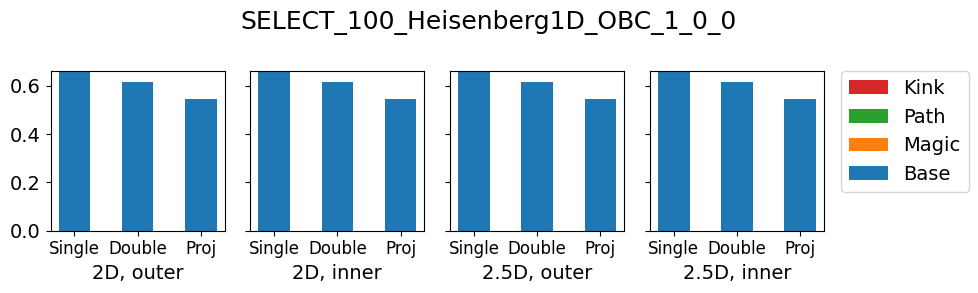

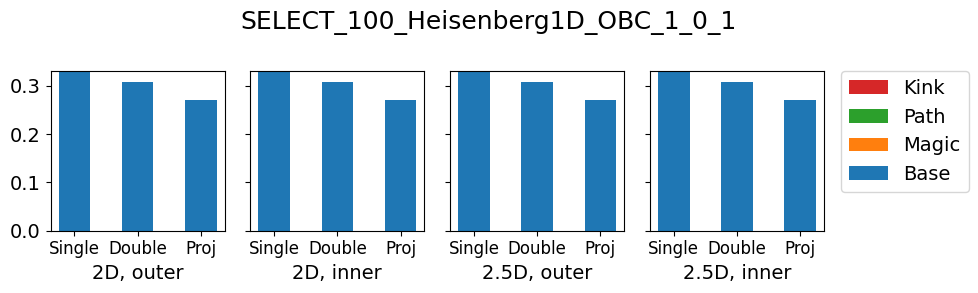

Kink 7.48839299086479e-05


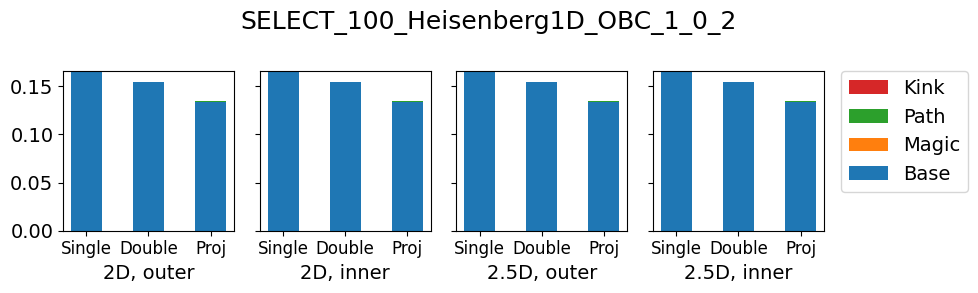

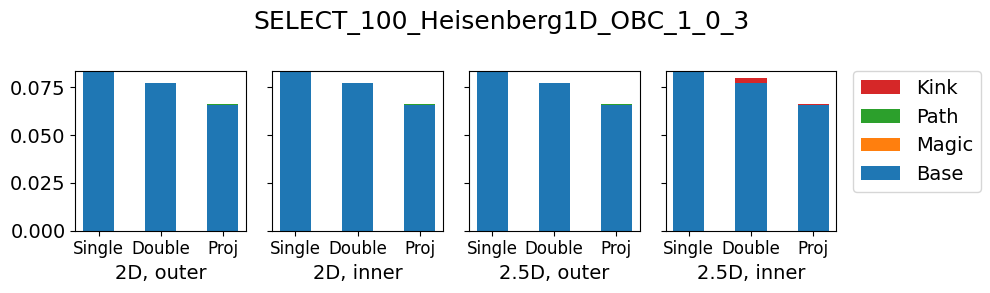

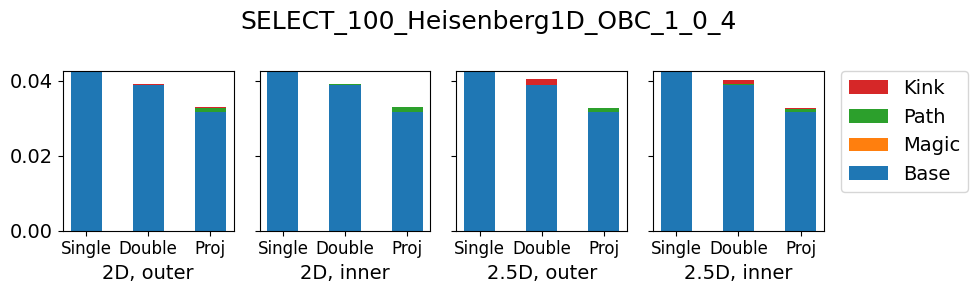

Path 6.499415052645466e-05


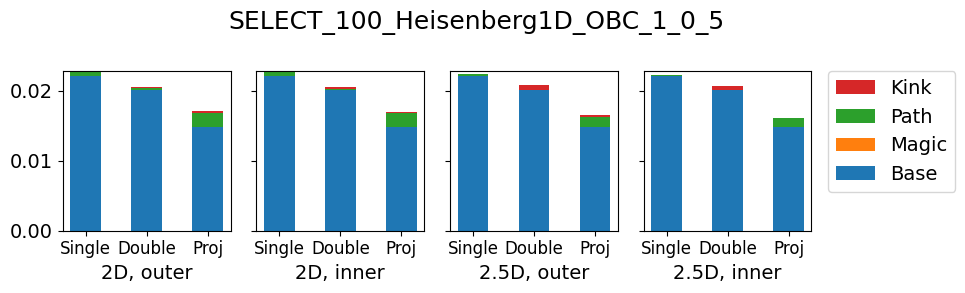

Kink 5.704506560182468e-05


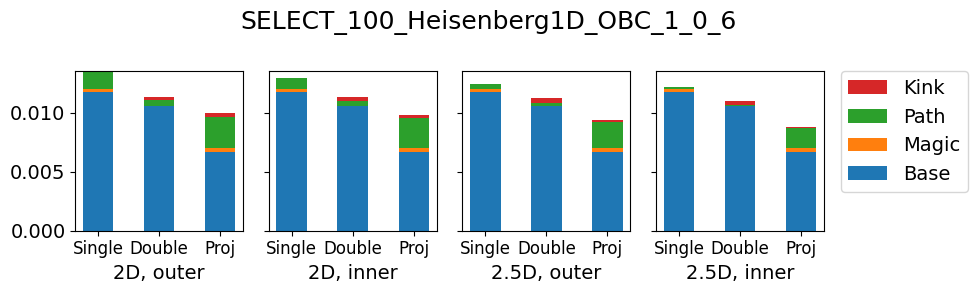

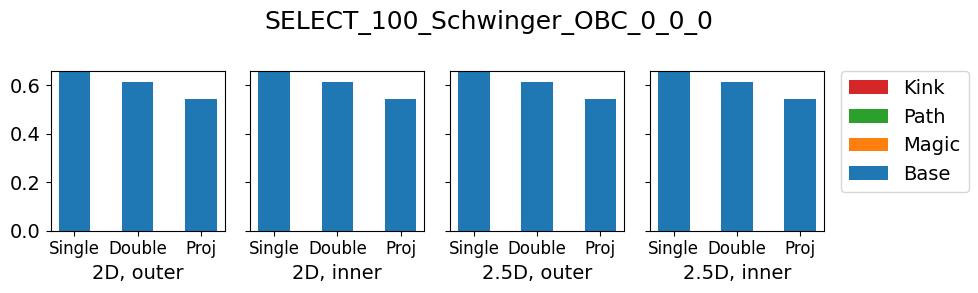

Kink 1.7651315905586884e-05
Kink 1.7651315905586884e-05


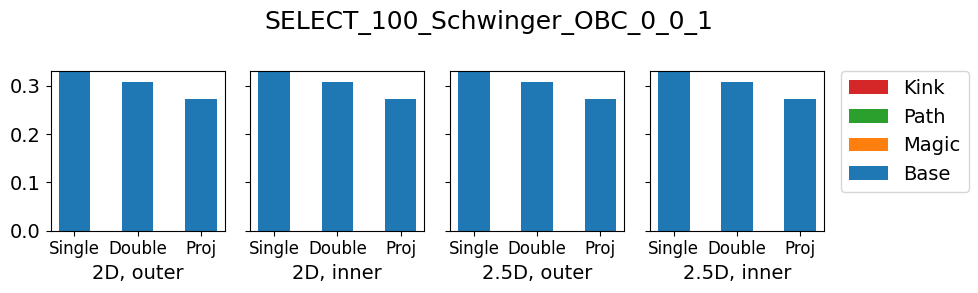

Kink 1.7587365236826358e-05


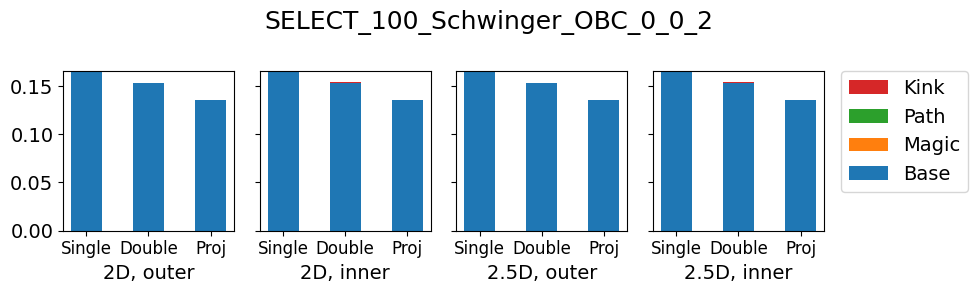

Kink 1.7469384902948915e-05


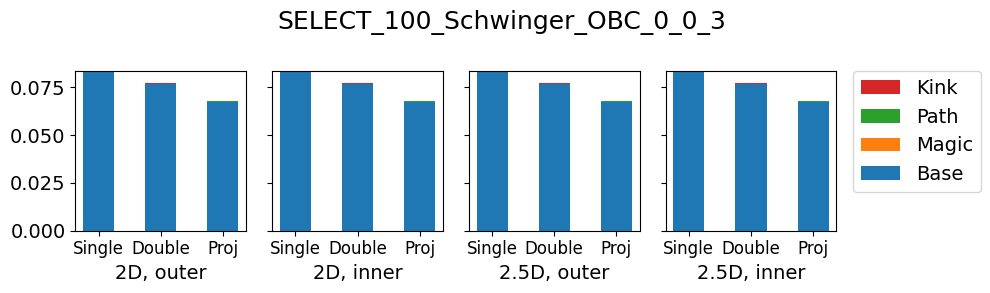

Kink 1.724048756098634e-05


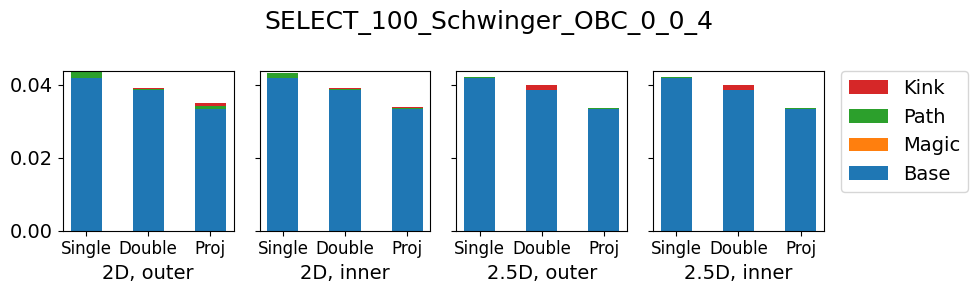

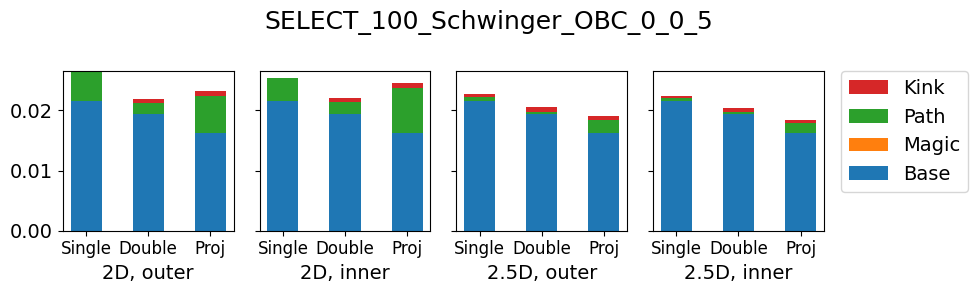

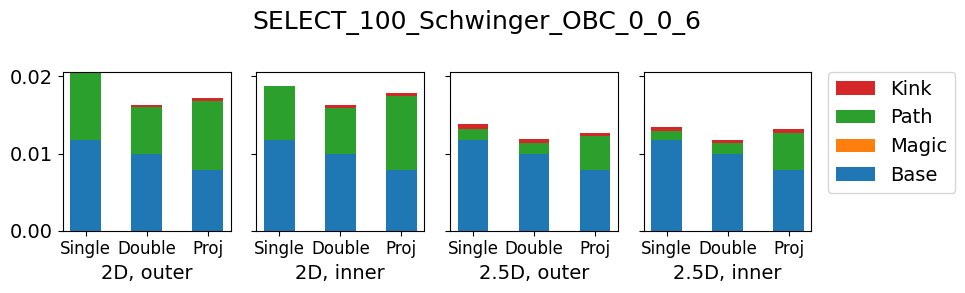

Kink 0.00015384615384617106


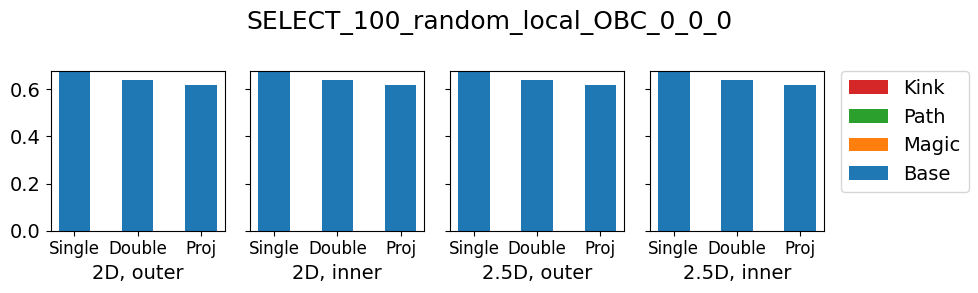

Kink 7.669888019634641e-05


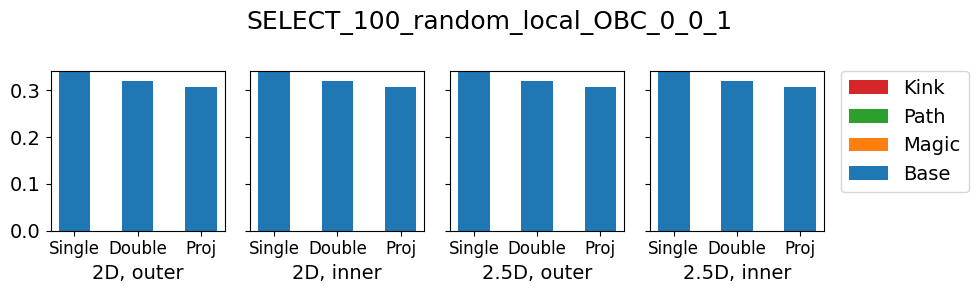

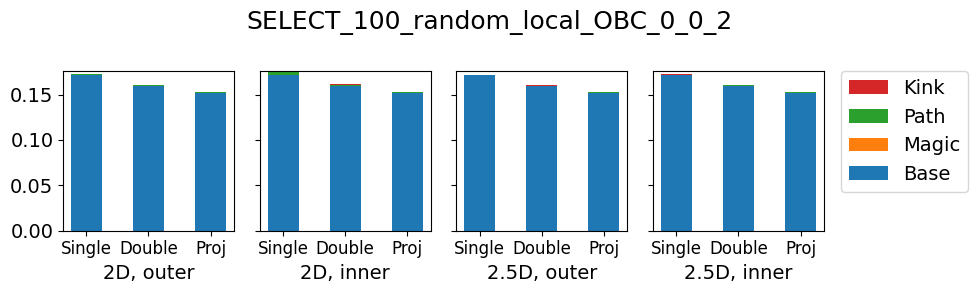

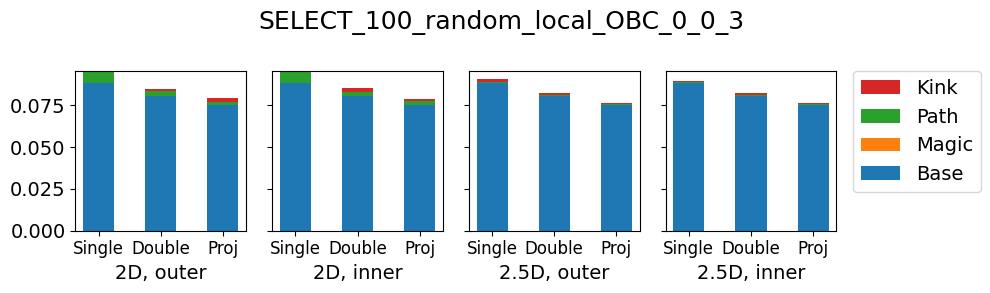

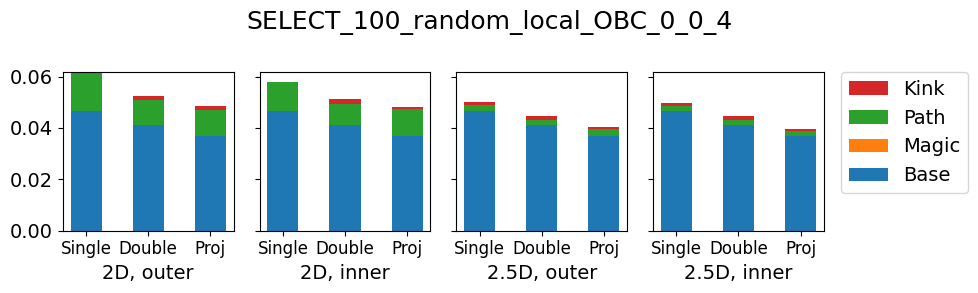

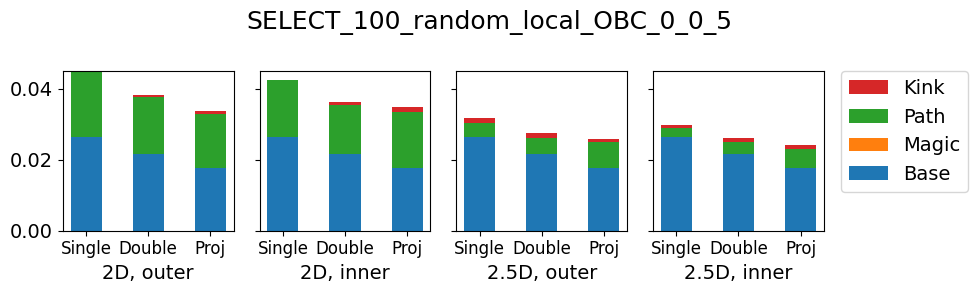

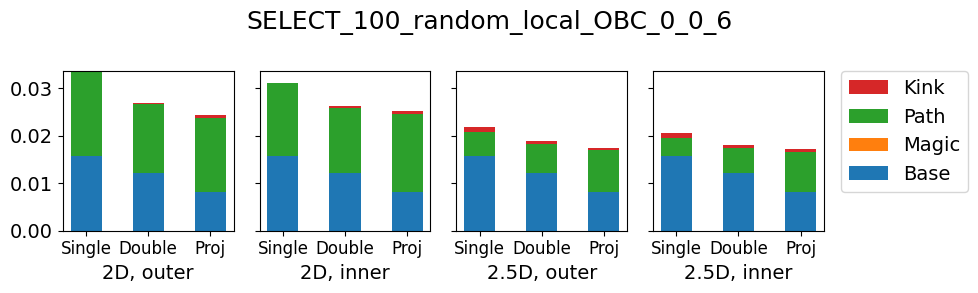

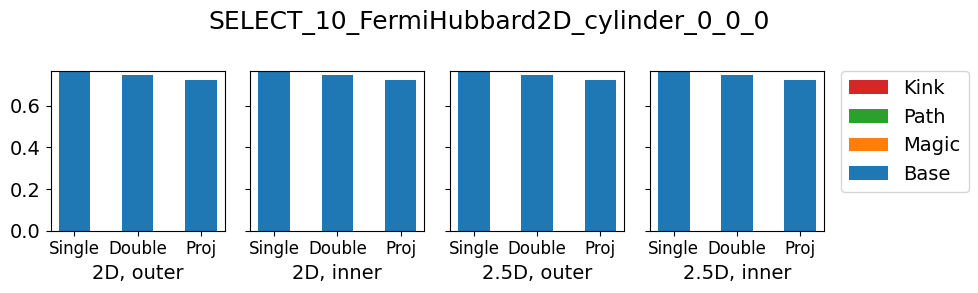

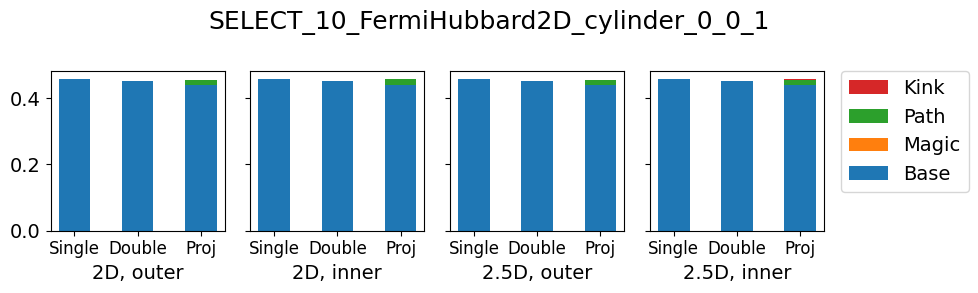

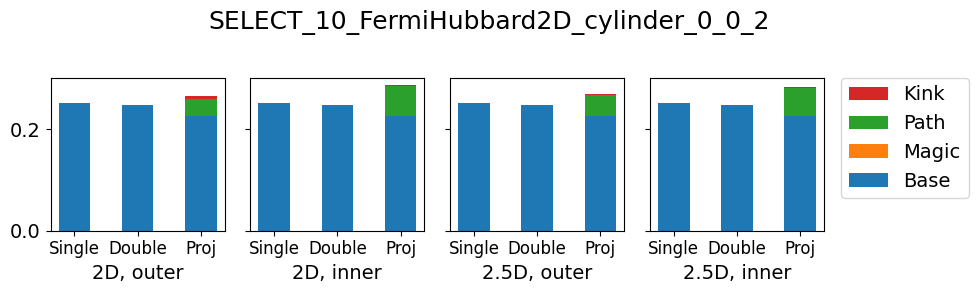

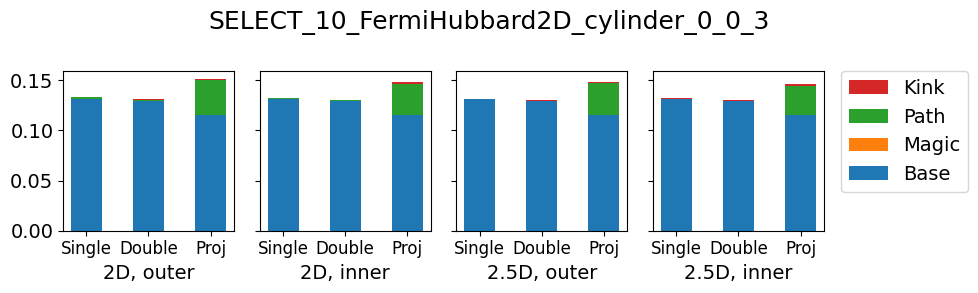

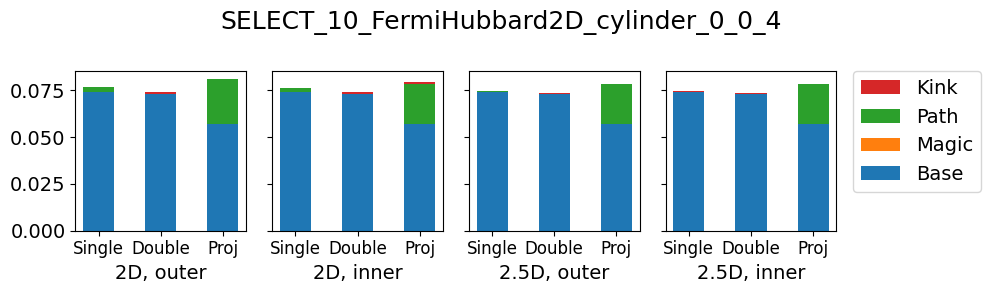

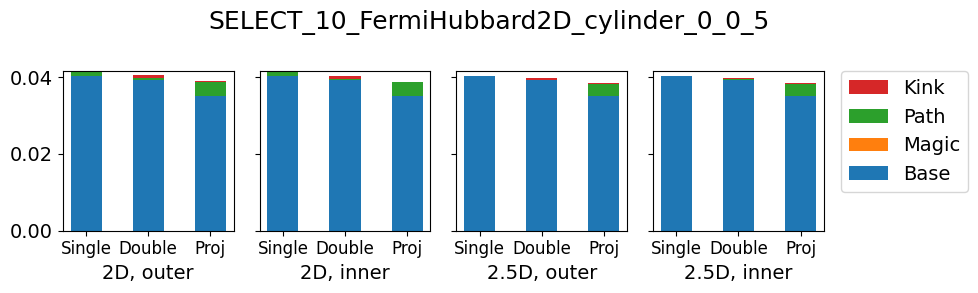

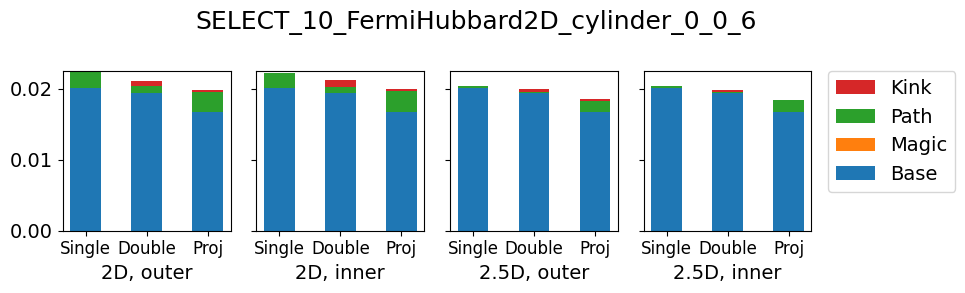

Kink 8.168599901980933e-05


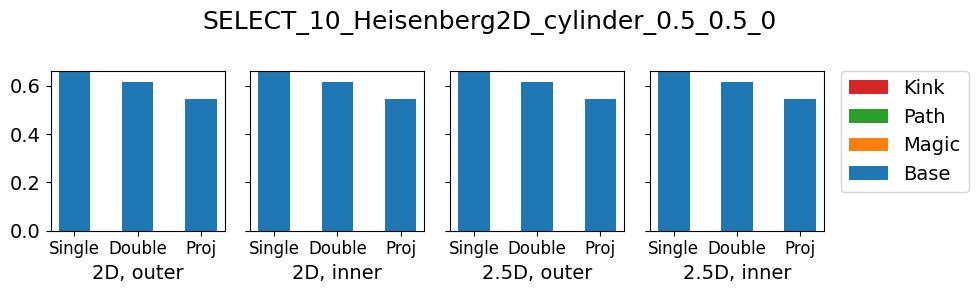

Kink 8.120838070485581e-05


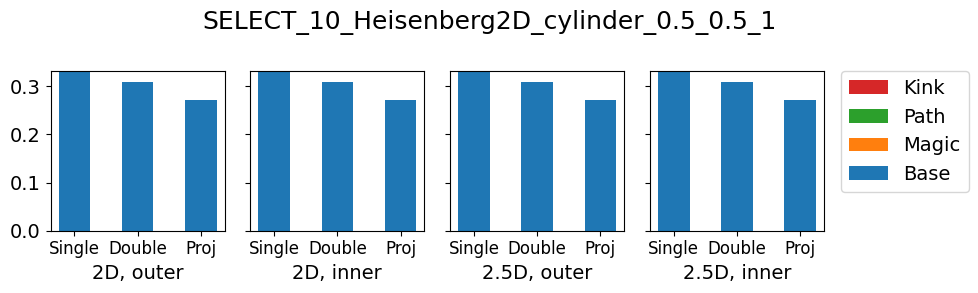

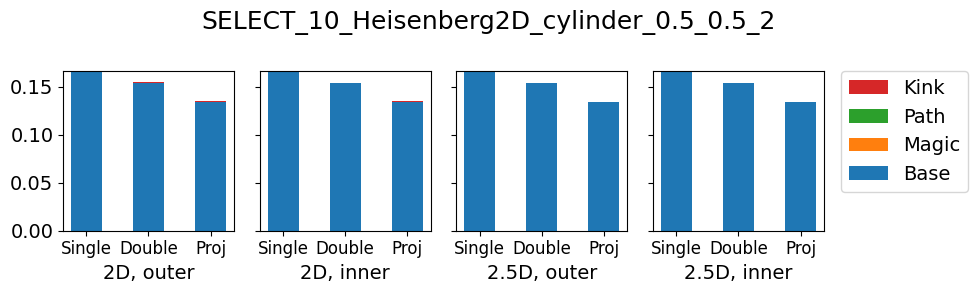

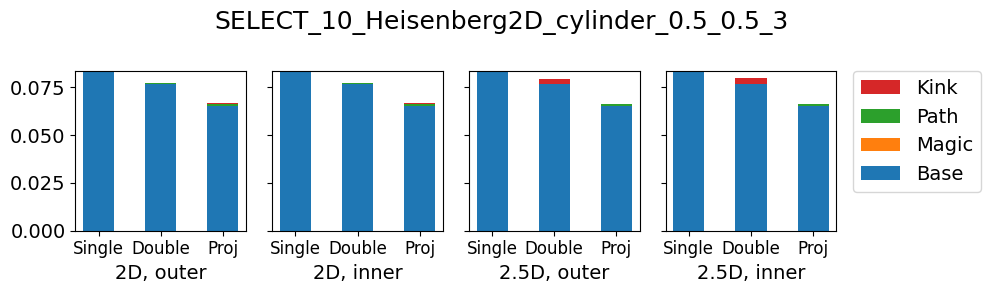

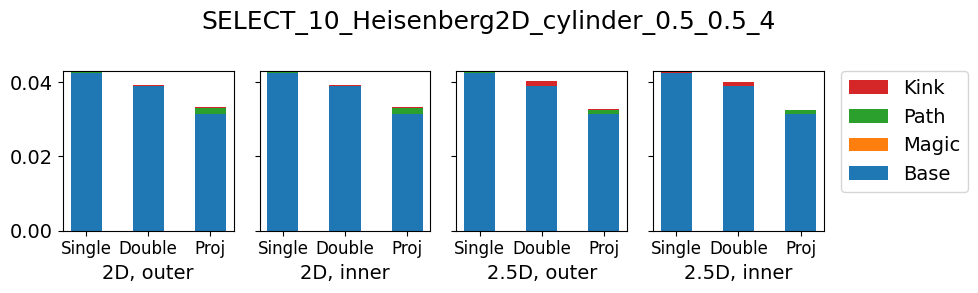

Path 6.839009711393645e-05


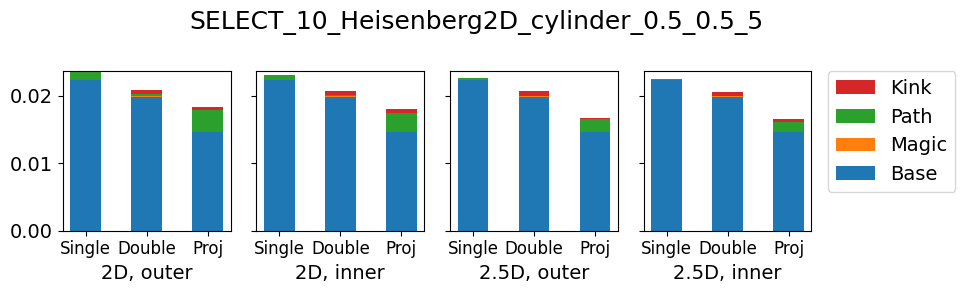

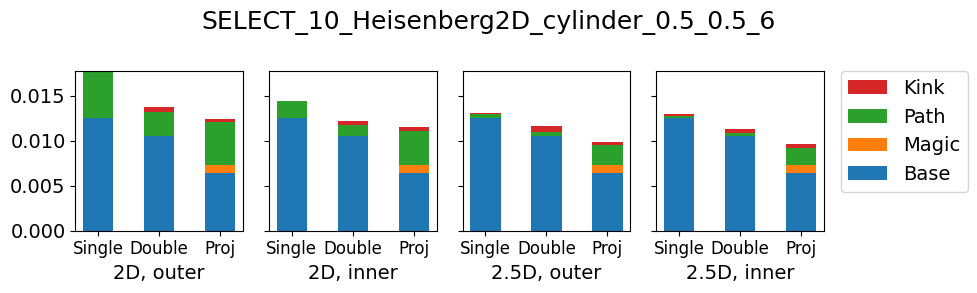

Kink 0.00030156815440285367


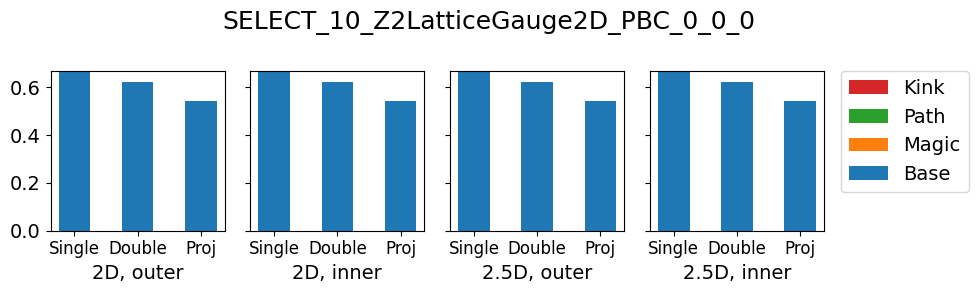

Kink 0.0002969121140142805


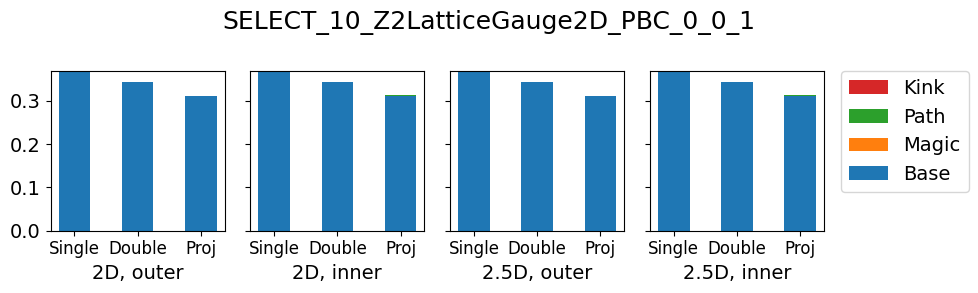

Kink 0.0002849002849003024


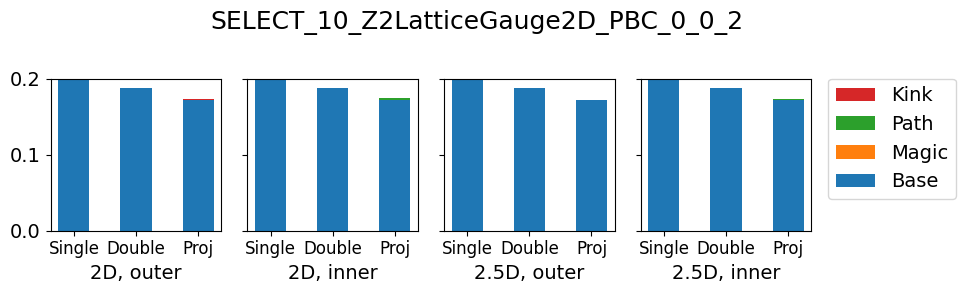

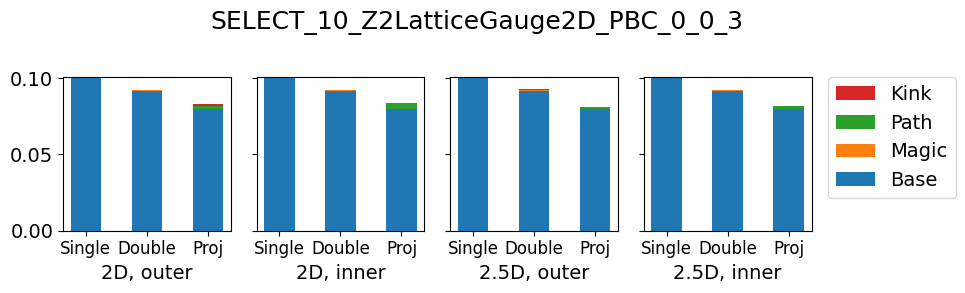

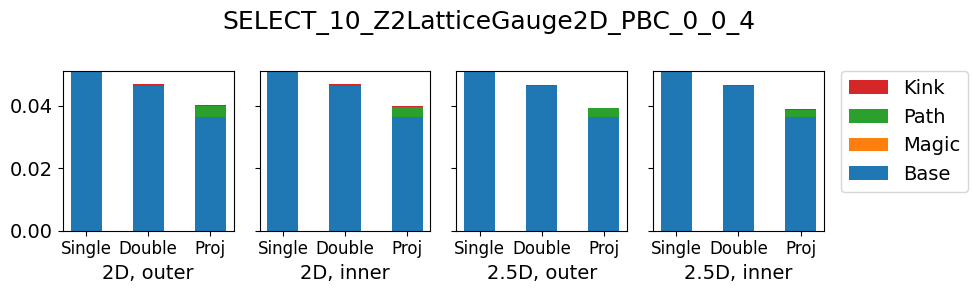

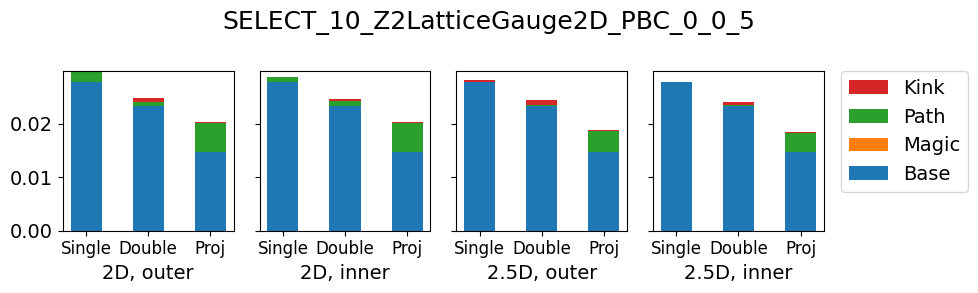

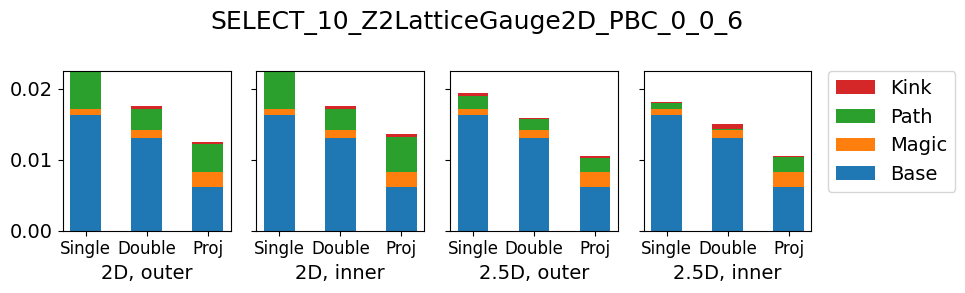

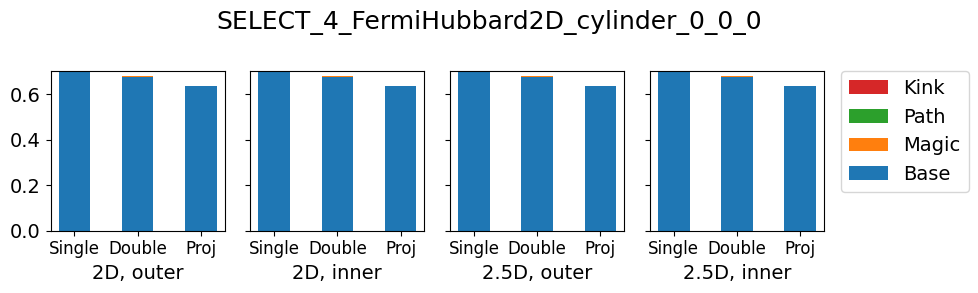

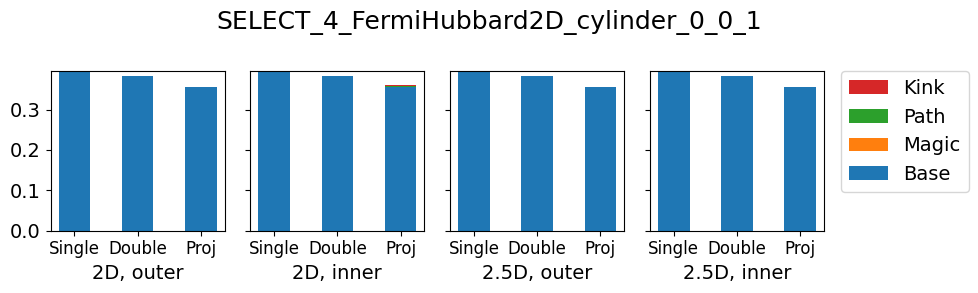

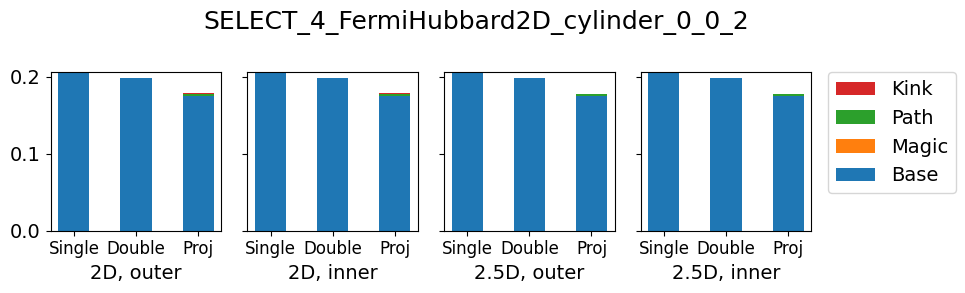

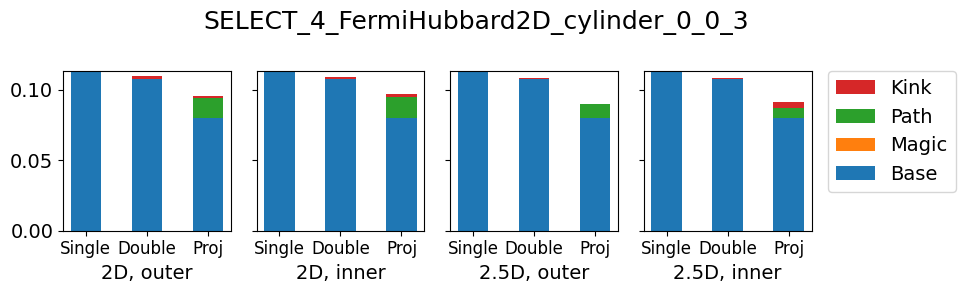

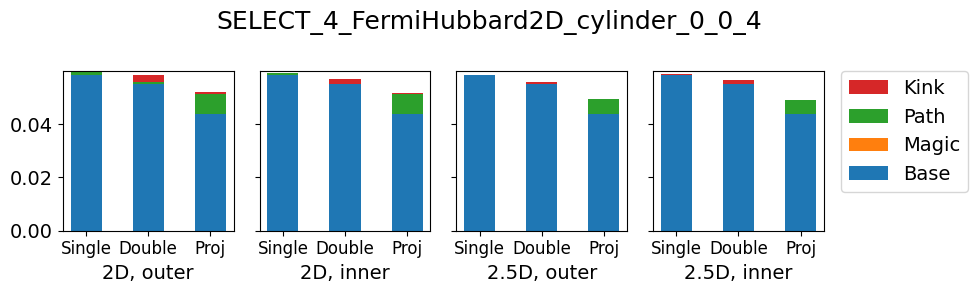

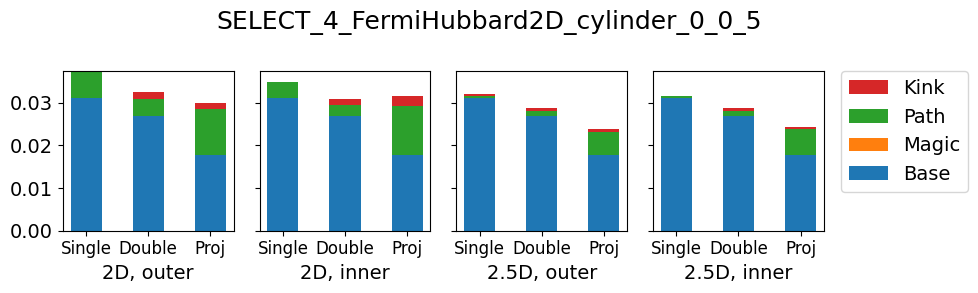

Kink 0.00018910741301059186


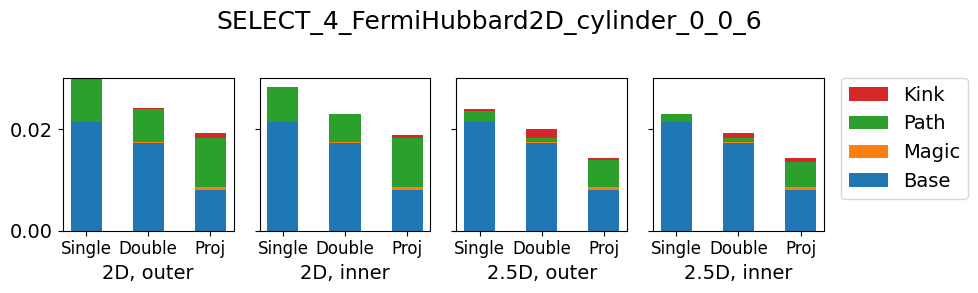

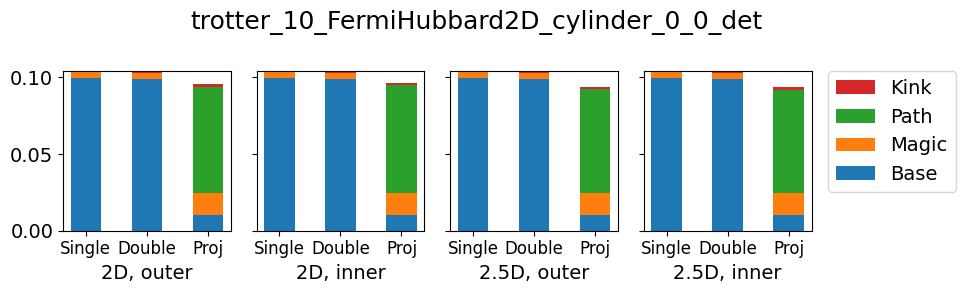

Path 8.205689277898665e-05
Path 2.7352297593000174e-05
Path 8.205689277898665e-05


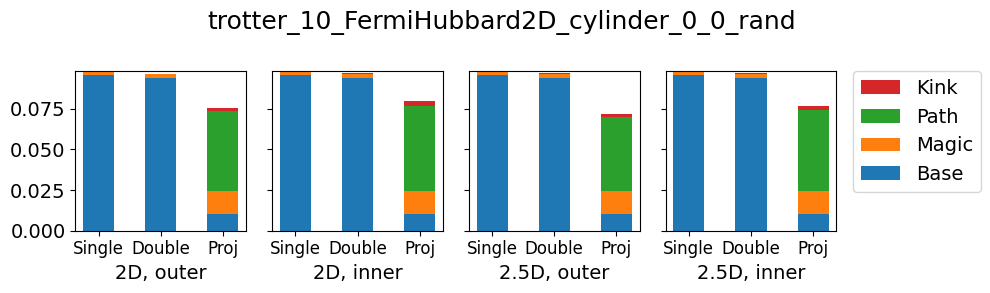

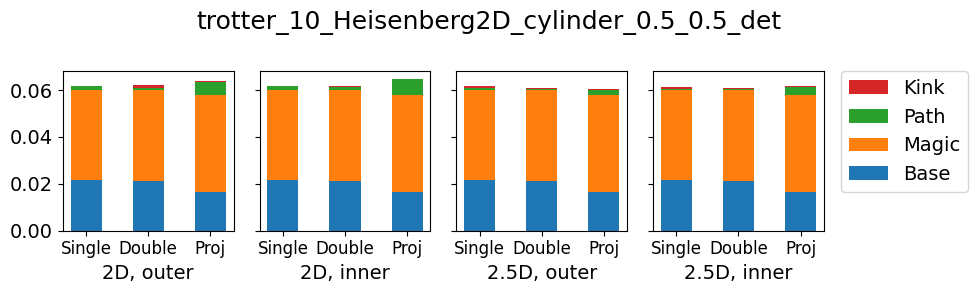

Path 0.0002032520325203277
Path 0.00027100271002709897
Path 0.00027100271002709897
Kink 0.0002032520325203277
Path 6.775067750677127e-05
Kink 0.00027100271002709897


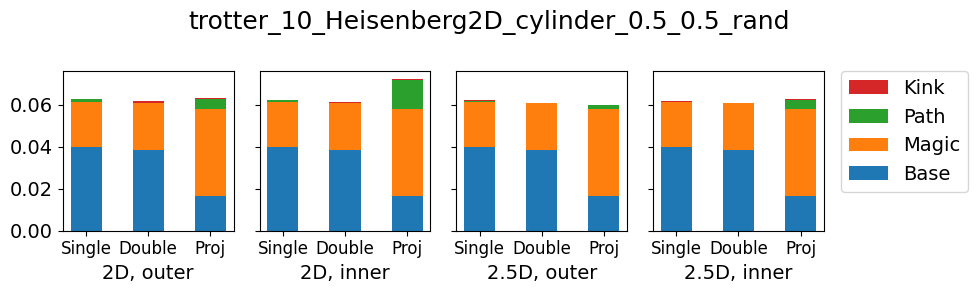

Kink 0.0013440860215053752


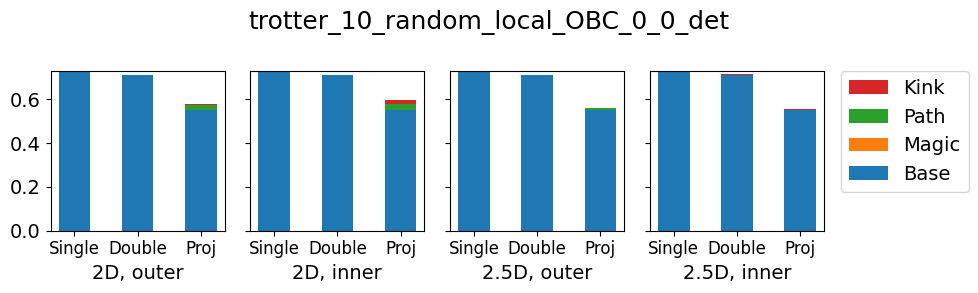

Kink 0.0026881720430107503


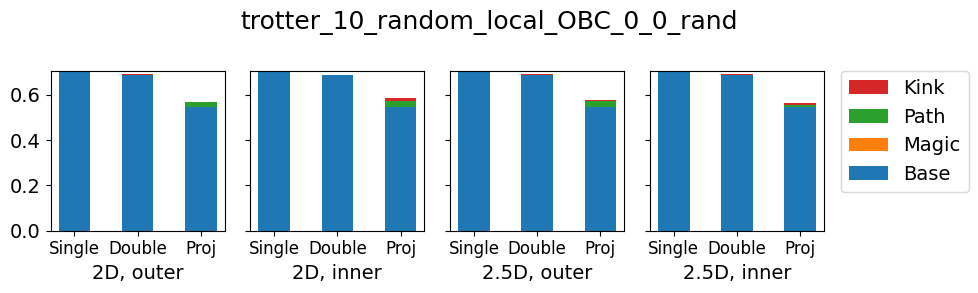

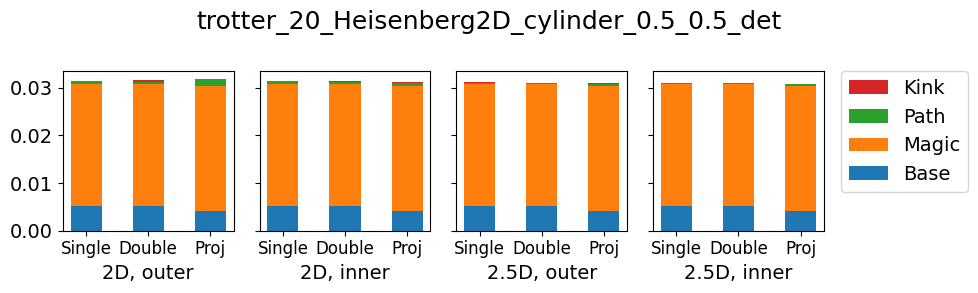

Path 1.646903820816739e-05
Path 1.646903820816739e-05
Path 1.646903820816739e-05
Kink 1.646903820816739e-05


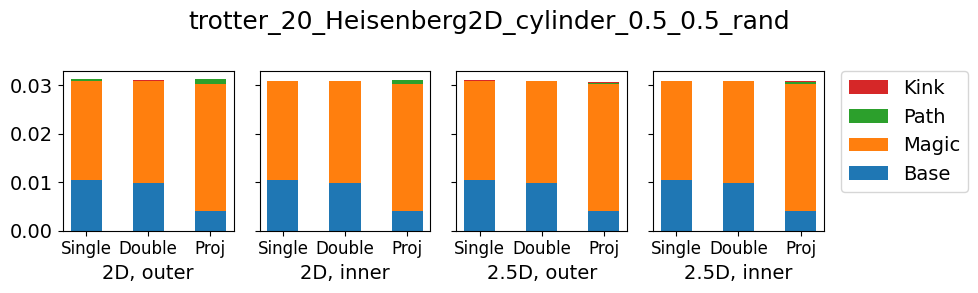

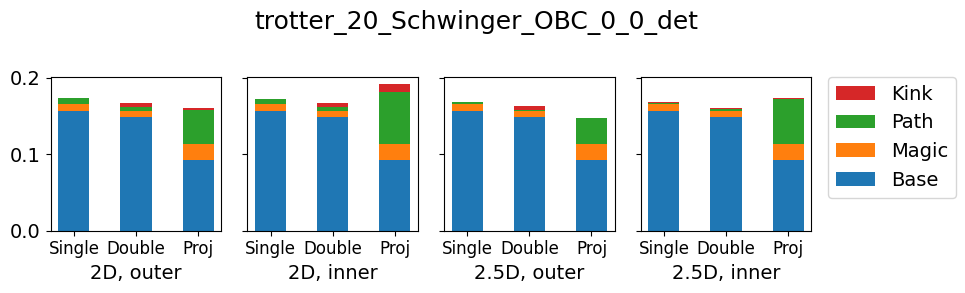

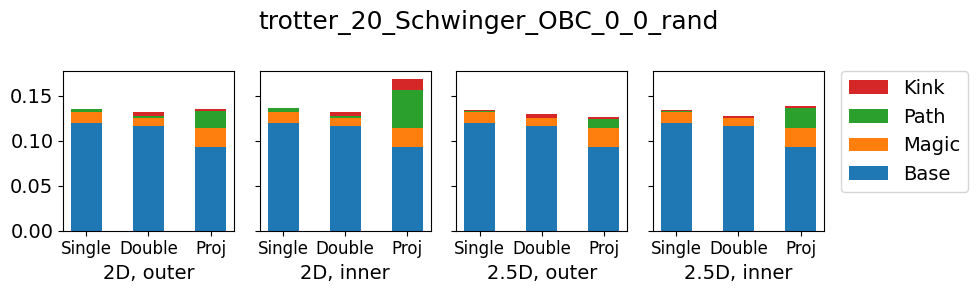

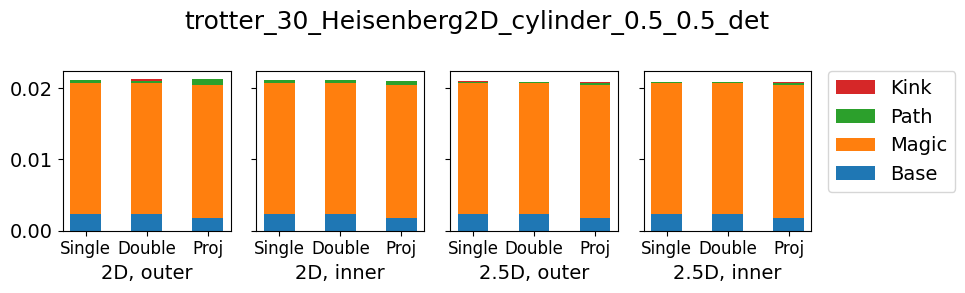

Path 7.252683492893486e-06
Path 7.252683492893486e-06
Path 7.252683492893486e-06
Path 7.252683492893486e-06
Kink 7.252683492893486e-06


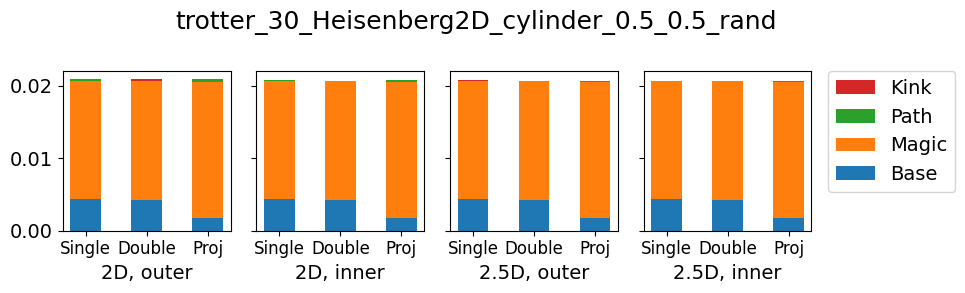

Path 0.0002460629921259838


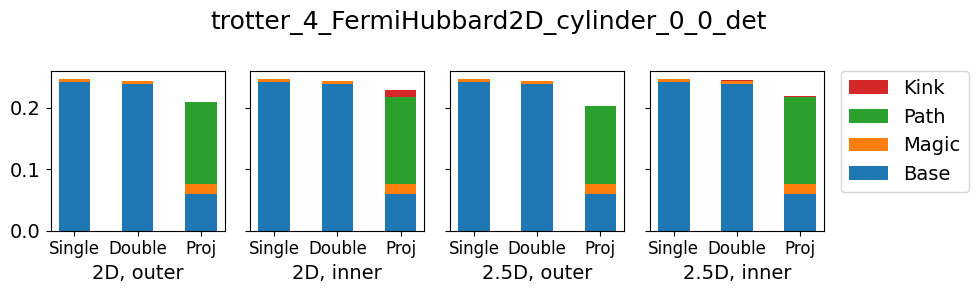

Path 0.0007381889763779514
Path 0.0004921259842519676
Path 0.0007381889763779514
Path 0.0007381889763779514


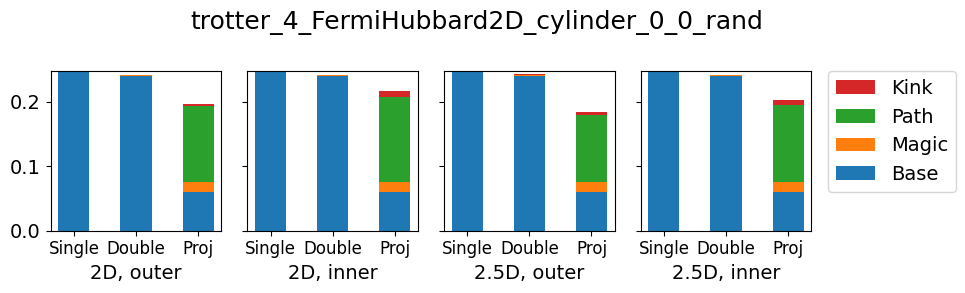

Path 0.001388888888888884
Path 0.0009259259259259134


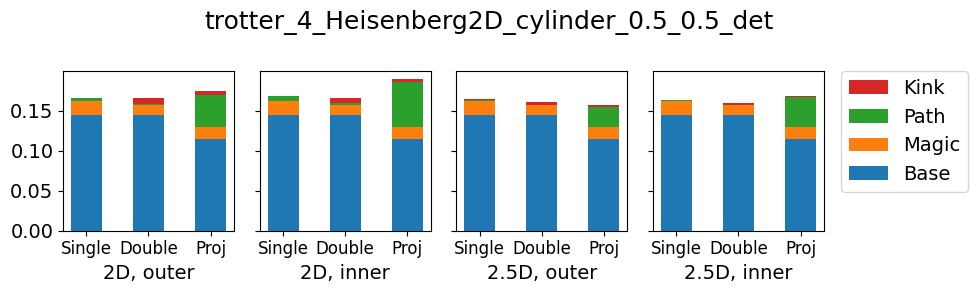

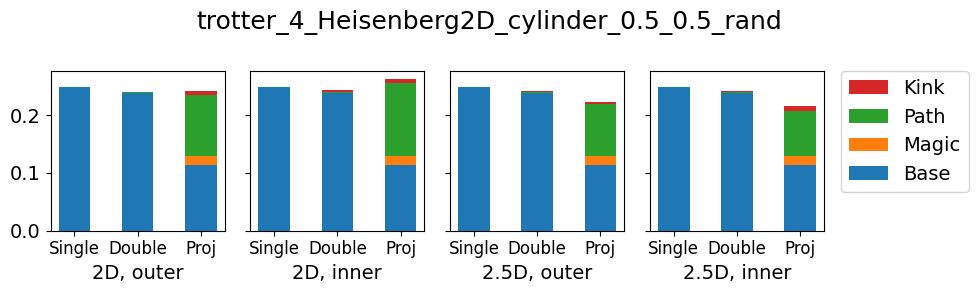

In [ ]:
df_best_sa = df_best[df_best["allocator"] == "SA"]
for circuit, df_circuit in sorted(df_best_sa.groupby("circuit")):
    plot_circuit_wise(circuit, df_circuit, True)

# Comparison between Naive, Random, and SA

In [ ]:
df_ex = df[
    (df["circuit"] == "result_SELECT_10_FermiHubbard2D_cylinder_0_0_5")
    & (df["routing_algo"] == "Double")
    & (df["routing_option"] == "Yes_Kink")
]
idx = df_ex.groupby(
    [
        "circuit",
        "factory",
        "layer count",
        "allocator",
        "routing_algo",
        "routing_option",
    ]
)["total code beat"].idxmin()
df_ex_best = df_ex.loc[idx]
df_ex_best.sort_values(
    [
        "layer count",
        "factory",
        "allocator",
    ],
    ascending=[True, False, True],
    inplace=True,
)
display(df_ex_best)

,circuit,factory,layer count,allocator,msf coeff,routing_algo,routing_option,total code beat,circuit volume,instruction_count,cbpi
9545,result_SELECT_10_FermiHubbard2D_cylinder_0_0_5,outer,1,SA,0.100,Double,Yes_Kink,888,731462,21914,0.041
9572,result_SELECT_10_FermiHubbard2D_cylinder_0_0_5,outer,1,naive,0.000,Double,Yes_Kink,1099,1260759,21914,0.050
9585,result_SELECT_10_FermiHubbard2D_cylinder_0_0_5,outer,1,random,0.000,Double,Yes_Kink,897,1391131,21914,0.041
9418,result_SELECT_10_FermiHubbard2D_cylinder_0_0_5,inner,1,SA,1.000,Double,Yes_Kink,882,694111,21914,0.040
9431,result_SELECT_10_FermiHubbard2D_cylinder_0_0_5,inner,1,naive,0.000,Double,Yes_Kink,1099,1260759,21914,0.050
9447,result_SELECT_10_FermiHubbard2D_cylinder_0_0_5,inner,1,random,0.000,Double,Yes_Kink,897,1348218,21914,0.041
9613,result_SELECT_10_FermiHubbard2D_cylinder_0_0_5,outer,2,SA,0.100,Double,Yes_Kink,871,661812,21914,0.040
9641,result_SELECT_10_FermiHubbard2D_cylinder_0_0_5,outer,2,naive,0.000,Double,Yes_Kink,990,983402,21914,0.045
9653,result_SELECT_10_FermiHubbard2D_cylinder_0_0_5,outer,2,random,0.000,Double,Yes_Kink,874,985622,21914,0.040
9467,result_SELECT_10_FermiHubbard2D_cylinder_0_0_5,inner,2,SA,0.010,Double,Yes_Kink,871,625135,21914,0.040


,circuit,factory,layer count,allocator,msf coeff,routing_algo,routing_option,total code beat,circuit volume,instruction_count,cbpi
8732,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,1,naive,0.000,Double,No_MSF,4869,1108424,19658,0.248
8733,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,1,naive,0.000,Double,No_Top,4869,1125750,19658,0.248
8735,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,1,naive,0.000,Double,No_Kink,4882,1541855,19658,0.248
8736,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,1,naive,0.000,Proj,No_MSF,4442,30580,19658,0.226
8737,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,1,naive,0.000,Proj,No_Top,4442,48052,19658,0.226
8738,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,1,naive,0.000,Double,Yes_Kink,4885,1550089,19658,0.248
8740,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,1,naive,0.000,Single,No_MSF,4940,1124311,19658,0.251
8741,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,1,naive,0.000,Single,No_Top,4940,1141703,19658,0.251
8742,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,1,naive,0.000,Single,No_Kink,4952,1548635,19658,0.252
8743,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,1,random,0.000,Double,No_MSF,4869,1108424,19658,0.248


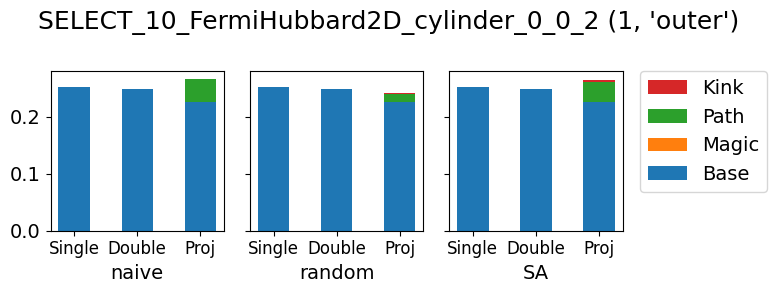

,circuit,factory,layer count,allocator,msf coeff,routing_algo,routing_option,total code beat,circuit volume,instruction_count,cbpi
8594,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,1,naive,0.000,Double,No_MSF,4869,1108424,19658,0.248
8597,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,1,naive,0.000,Double,No_Top,4869,1125750,19658,0.248
8598,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,1,naive,0.000,Proj,No_MSF,4442,30580,19658,0.226
8599,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,1,naive,0.000,Proj,No_Top,4442,48052,19658,0.226
8600,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,1,naive,0.000,Double,No_Kink,4882,1541855,19658,0.248
8601,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,1,naive,0.000,Double,Yes_Kink,4885,1550089,19658,0.248
8602,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,1,naive,0.000,Single,No_MSF,4940,1124311,19658,0.251
8603,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,1,naive,0.000,Single,No_Top,4940,1141703,19658,0.251
8604,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,1,naive,0.000,Single,No_Kink,4952,1548635,19658,0.252
8605,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,1,random,0.000,Double,No_MSF,4869,1108424,19658,0.248


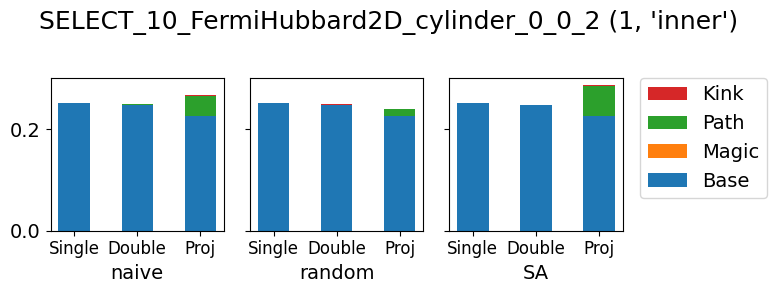

,circuit,factory,layer count,allocator,msf coeff,routing_algo,routing_option,total code beat,circuit volume,instruction_count,cbpi
8802,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,2,naive,0.000,Double,No_Kink,4872,1375528,19658,0.248
8803,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,2,naive,0.000,Double,No_MSF,4869,1108424,19658,0.248
8804,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,2,naive,0.000,Double,No_Top,4869,1125750,19658,0.248
8805,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,2,naive,0.000,Double,Yes_Kink,4891,1384076,19658,0.249
8807,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,2,naive,0.000,Proj,No_Top,4442,48052,19658,0.226
8808,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,2,naive,0.000,Proj,No_MSF,4442,30580,19658,0.226
8810,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,2,naive,0.000,Single,No_MSF,4940,1124311,19658,0.251
8811,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,2,naive,0.000,Single,No_Kink,4940,1371878,19658,0.251
8812,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,2,naive,0.000,Single,No_Top,4940,1141703,19658,0.251
8813,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,outer,2,naive,0.000,Single,Yes_Kink,4940,1395486,19658,0.251


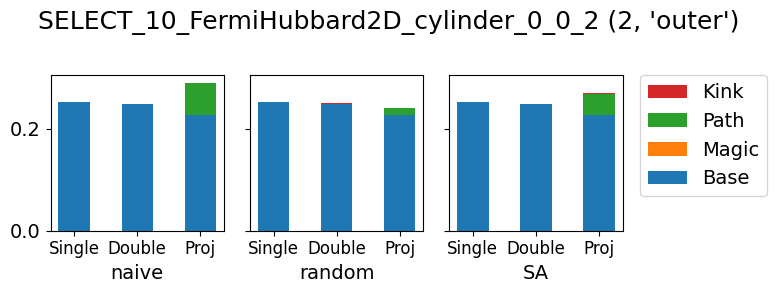

,circuit,factory,layer count,allocator,msf coeff,routing_algo,routing_option,total code beat,circuit volume,instruction_count,cbpi
8664,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,2,naive,0.000,Double,No_Kink,4872,1375528,19658,0.248
8665,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,2,naive,0.000,Double,No_MSF,4869,1108424,19658,0.248
8666,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,2,naive,0.000,Double,No_Top,4869,1125750,19658,0.248
8667,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,2,naive,0.000,Double,Yes_Kink,4891,1384076,19658,0.249
8668,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,2,naive,0.000,Proj,No_MSF,4442,30580,19658,0.226
8669,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,2,naive,0.000,Proj,No_Top,4442,48052,19658,0.226
8672,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,2,naive,0.000,Single,No_MSF,4940,1124311,19658,0.251
8673,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,2,naive,0.000,Single,No_Top,4940,1141703,19658,0.251
8674,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,2,naive,0.000,Single,No_Kink,4940,1371878,19658,0.251
8675,result_SELECT_10_FermiHubbard2D_cylinder_0_0_2,inner,2,naive,0.000,Single,Yes_Kink,4940,1395486,19658,0.251


Kink 0.000356089124020742


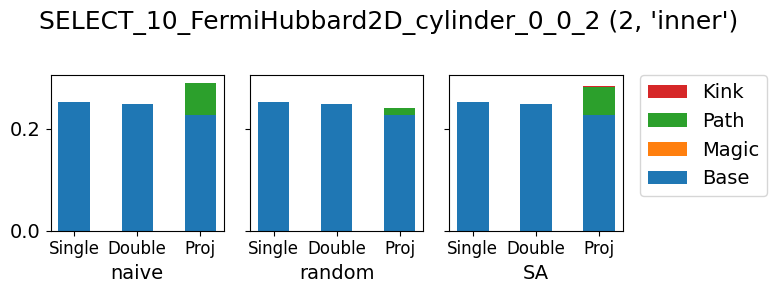

In [ ]:
def plot_circuit_wise_with_naive_random_SA(
    circuit: str,
    option: tuple[str, str],
    df_circuit: pd.DataFrame,
    save: bool = False,
    save_dir: str = "../../fig/cbpi_stack",
) -> None:
    if save:
        os.makedirs(save_dir, exist_ok=True)

    ax_labels = ["naive", "random", "SA"]

    fig, axes = plt.subplots(
        1,
        len(ax_labels),
        figsize=(2 * len(ax_labels) + 2, 3),
        sharex=True,
        sharey=True,
    )

    for ax, ax_label in zip(axes, ax_labels):
        df_ax = df_circuit[df_circuit["allocator"] == ax_label]
        # display(df_ax)
        draw(ax, df_ax)

    fig.suptitle(circuit.replace("result_", "") + " " + str(option), fontsize=18)
    for j, ax_label in enumerate(ax_labels):
        axes[j].set_xlabel(ax_label)

    handles, labels = axes[-1].get_legend_handles_labels()
    axes[-1].legend(
        handles=handles[::-1],
        labels=labels[::-1],
        bbox_to_anchor=(1.1, 1),
        loc="upper left",
        borderaxespad=0,
    )

    plt.tight_layout()
    if save:
        figname = os.path.join(save_dir, circuit + ".png")
        plt.savefig(figname)
    plt.show()


for circuit, df_circuit in sorted(df.groupby("circuit")):
    if not (circuit == "result_SELECT_10_FermiHubbard2D_cylinder_0_0_2"):
        continue
    for option in options:
        layer_count, factory = option
        df_option = df_circuit[
            (df_circuit["layer count"] == layer_count)
            & (df_circuit["factory"] == factory)
        ]
        df_option_sa = df_option[df_option["allocator"] == "SA"]
        idx = df_option_sa.groupby(
            [
                "circuit",
                "factory",
                "layer count",
                "allocator",
                "routing_algo",
                "routing_option",
            ]
        )["total code beat"].idxmin()
        df_option_best = pd.concat(
            (df_option[df_option["allocator"] != "SA"], df_option_sa.loc[idx])
        )
        display(df_option_best)
        plot_circuit_wise_with_naive_random_SA(circuit, option, df_option_best)
    # break

In [ ]:
from collections import defaultdict

idx = df.groupby(
    [
        "circuit",
        "factory",
        "layer count",
        "allocator",
        "routing_algo",
        "routing_option",
    ]
)["total code beat"].idxmin()
df_all_best = df.loc[idx]
ratio_dict_1 = defaultdict(lambda: (0.0, None))
ratio_dict_2 = defaultdict(lambda: (0.0, None))
for param, df_param in df_all_best.groupby(
    [
        "circuit",
        "factory",
        "layer count",
        "routing_algo",
        "routing_option",
    ]
):
    grp = df_param.groupby("allocator")["total code beat"]
    ratio_dict_1[param[0]] = max(
        ratio_dict_1[param[0]],
        (grp.get_group("random").item() / grp.get_group("naive").item(), param),
    )
    ratio_dict_2[param[0]] = max(
        ratio_dict_2[param[0]],
        (grp.get_group("SA").item() / grp.get_group("random").item(), param),
    )

In [ ]:
for ratio_dict in (ratio_dict_1, ratio_dict_2):
    print("\nRatio")
    for circuit, (ratio, param) in sorted(
        ratio_dict.items(), key=lambda t: t[1], reverse=True
    )[:10]:
        print(ratio, param)


Ratio
2.2850574712643676 ('result_trotter_10_random_local_OBC_0_0_rand', 'inner', 2, 'Proj', 'Yes_Kink')
1.8418367346938775 ('result_trotter_4_Heisenberg2D_cylinder_0.5_0.5_det', 'inner', 2, 'Proj', 'No_Kink')
1.7036553524804177 ('result_trotter_20_Schwinger_OBC_0_0_det', 'inner', 1, 'Proj', 'Yes_Kink')
1.6929012345679013 ('result_trotter_20_Schwinger_OBC_0_0_rand', 'inner', 1, 'Proj', 'Yes_Kink')
1.6207627118644068 ('result_trotter_4_Heisenberg2D_cylinder_0.5_0.5_rand', 'inner', 2, 'Proj', 'No_Kink')
1.4533195020746887 ('result_trotter_10_Heisenberg2D_cylinder_0.5_0.5_rand', 'inner', 1, 'Proj', 'Yes_Kink')
1.3234960272417706 ('result_trotter_4_FermiHubbard2D_cylinder_0_0_det', 'inner', 2, 'Proj', 'Yes_Kink')
1.2156626506024097 ('result_trotter_4_FermiHubbard2D_cylinder_0_0_rand', 'inner', 1, 'Proj', 'Yes_Kink')
1.2142616885301043 ('result_trotter_30_Heisenberg2D_cylinder_0.5_0.5_det', 'outer', 1, 'Single', 'No_Kink')
1.1931330472103003 ('result_SELECT_4_FermiHubbard2D_cylinder_0_0_4'

In [ ]:
for param, df_param in df_all_best.groupby(
    [
        "circuit",
        "factory",
        "layer count",
    ]
):
    display(df_param["routing_option"] == "Yes_")
    break

2216    False
2209    False
2210    False
2220    False
2243    False
2211    False
2208    False
2241    False
2217    False
2212    False
2213    False
2249    False
2247    False
2248    False
2251    False
2286    False
2250    False
2253    False
2287    False
2258    False
2255    False
2256    False
2261    False
2257    False
2260    False
2264    False
2301    False
2262    False
2263    False
2314    False
2268    False
2266    False
2267    False
Name: routing_option, dtype: bool

Kink 4565.0
Kink 78475.0
Kink 78033.0
Kink 42125.0


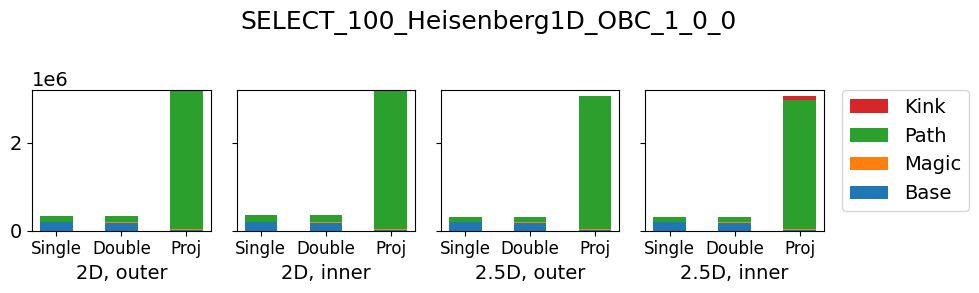

Kink 2064.0
Kink 37813.0
Kink 90582.0
Kink 33225.0


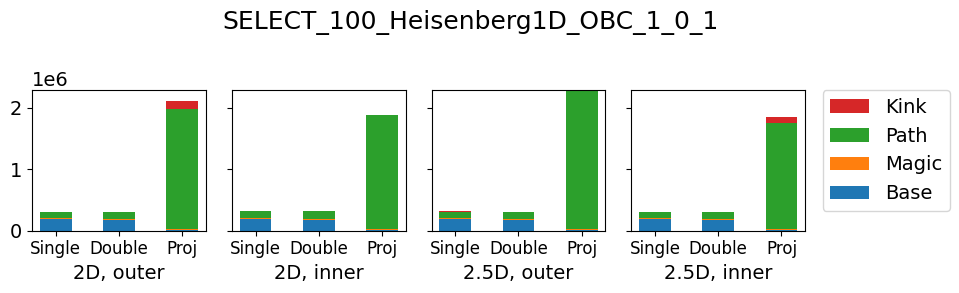

Kink 8868.0
Kink 36696.0
Kink 47515.0
Kink 96975.0


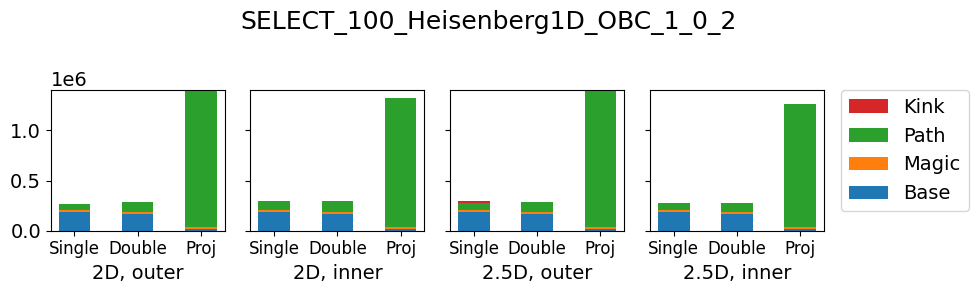

Kink 59656.0
Kink 72587.0
Kink 31180.0
Kink 23258.0


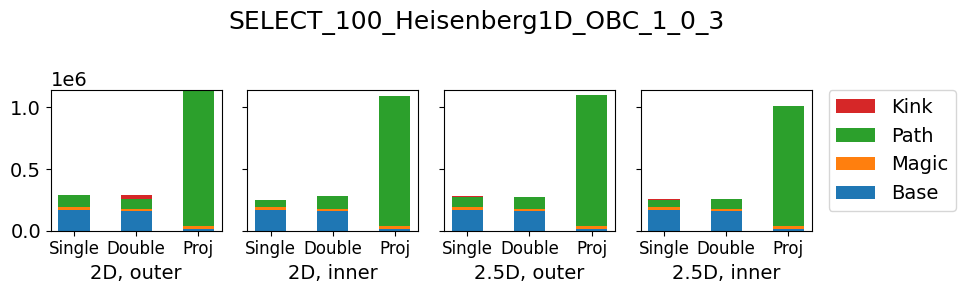

Kink 16195.0
Kink 18558.0
Kink 16284.0
Kink 13793.0


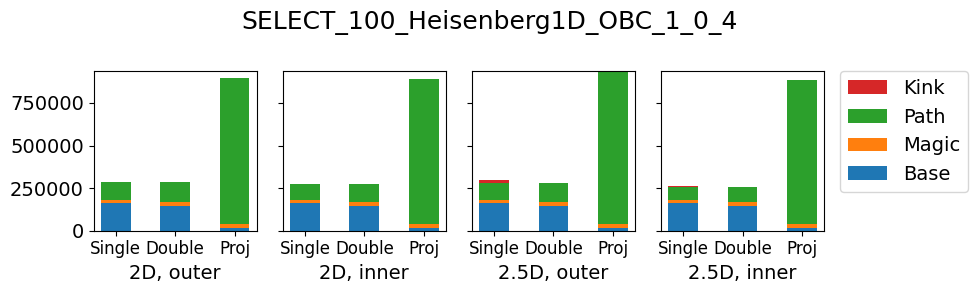

Kink 6158.0
Kink 21178.0
Kink 12177.0
Kink 11232.0


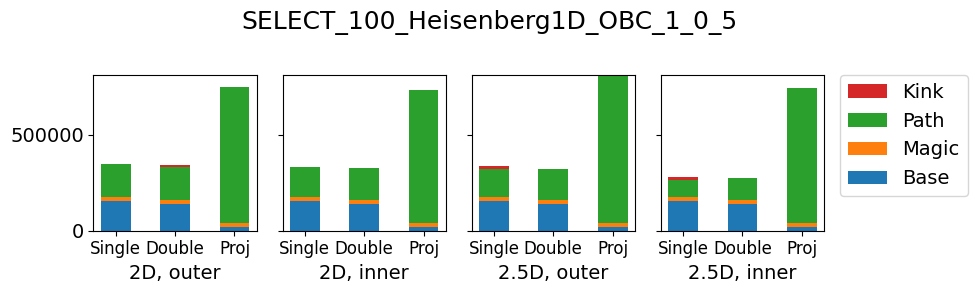

Kink 1149.0
Kink 5044.0


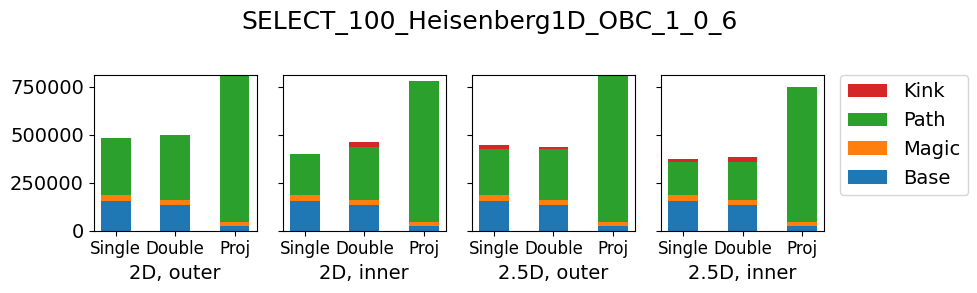

Kink 484689.0
Kink 319398.0
Kink 468253.0
Kink 352729.0


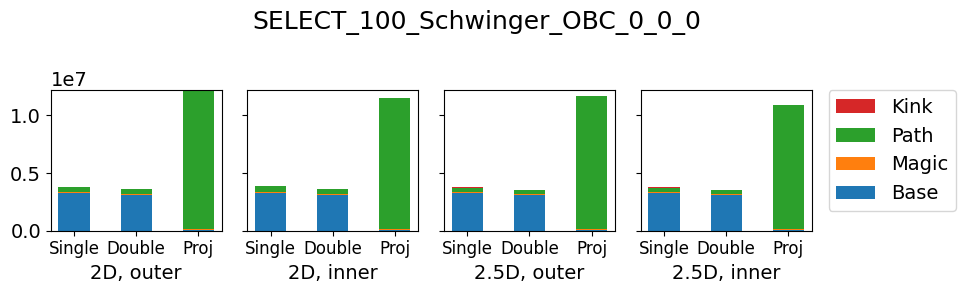

Kink 115012.0
Kink 124706.0
Kink 264088.0
Kink 257881.0


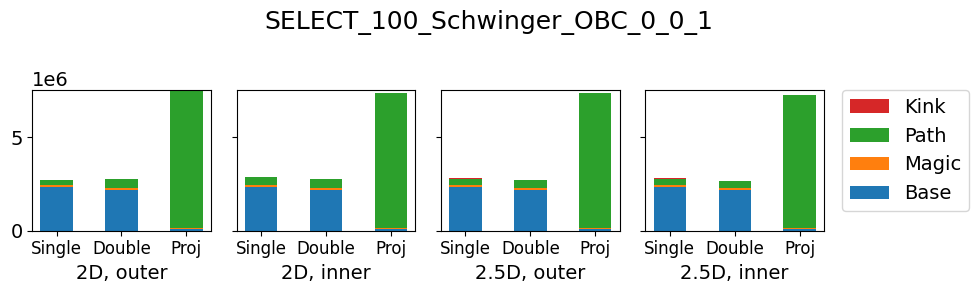

Kink 203234.0
Kink 11333.0
Kink 104685.0


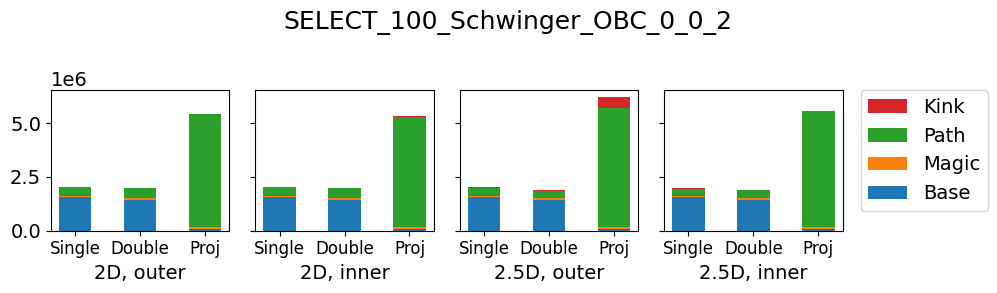

Kink 101047.0
Kink 136053.0
Kink 39430.0


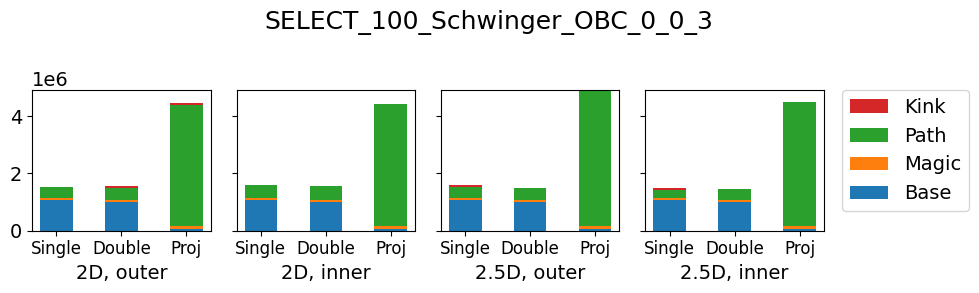

Kink 49629.0
Kink 41086.0
Kink 62206.0


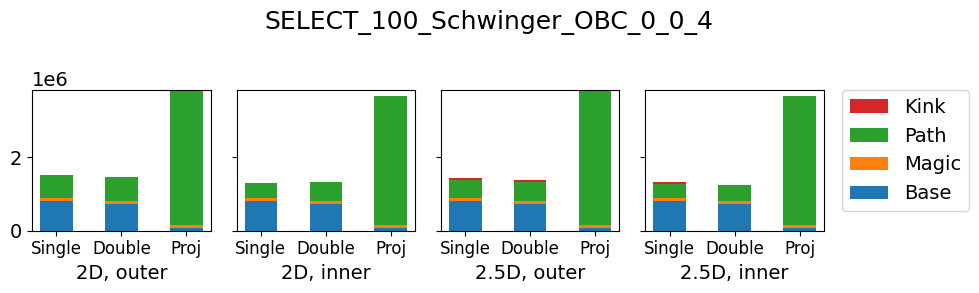

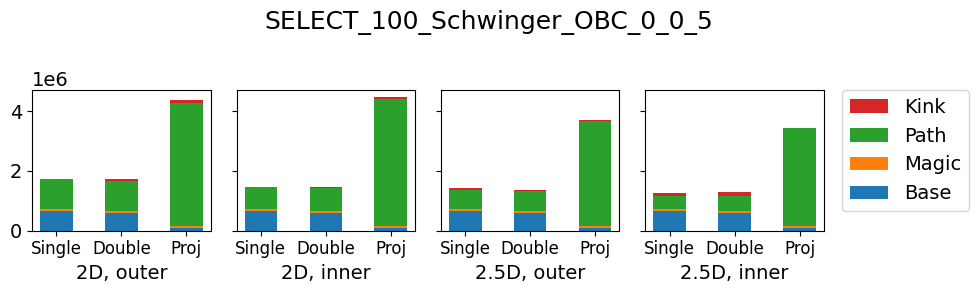

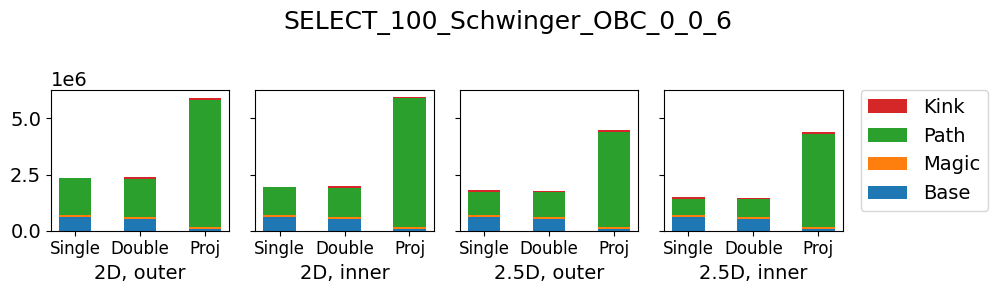

Kink 52883.0
Kink 28332.0
Kink 2655.0
Kink 123037.0


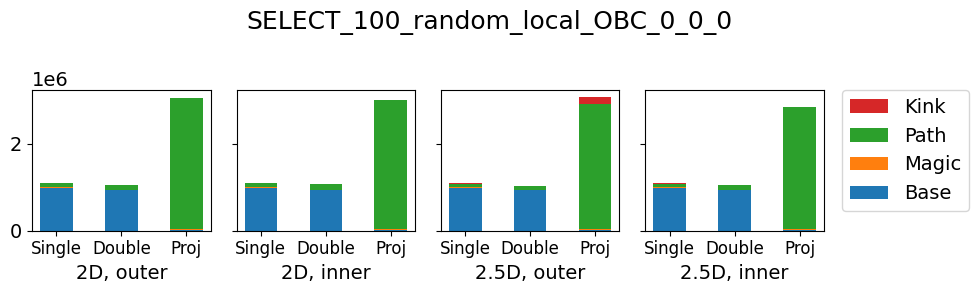

Kink 170742.0
Kink 88830.0
Kink 33931.0
Kink 83282.0


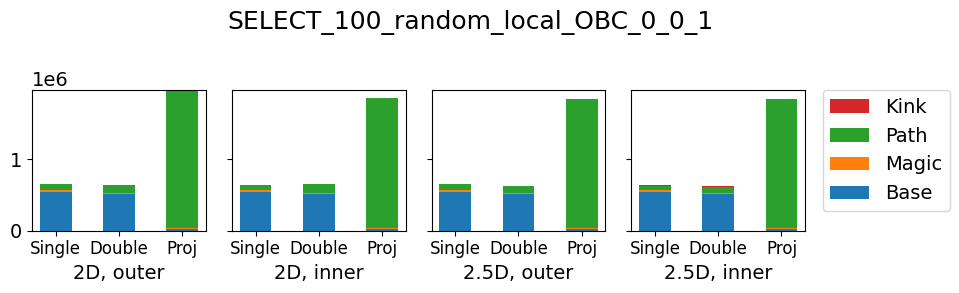

Kink 28284.0
Kink 20058.0
Kink 14620.0


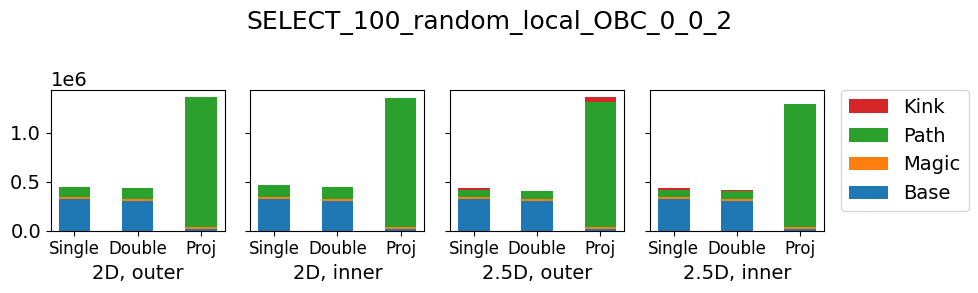

Kink 9162.0
Kink 17538.0
Kink 6769.0


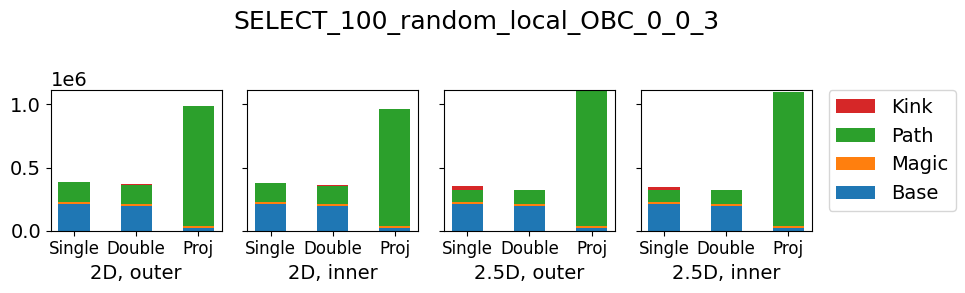

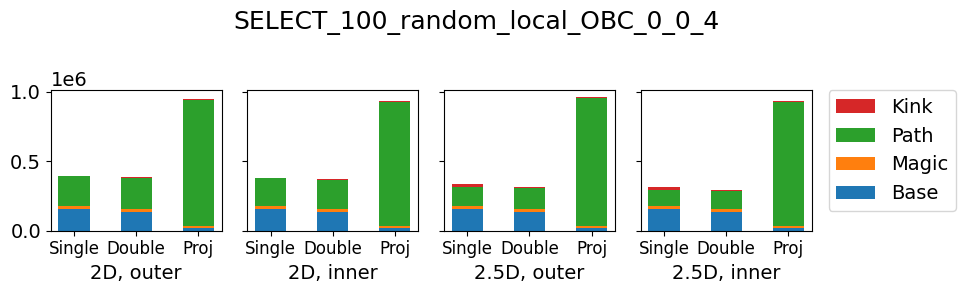

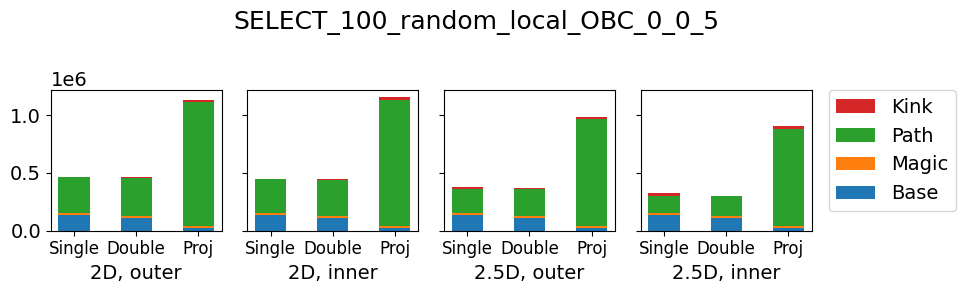

Kink 3755.0


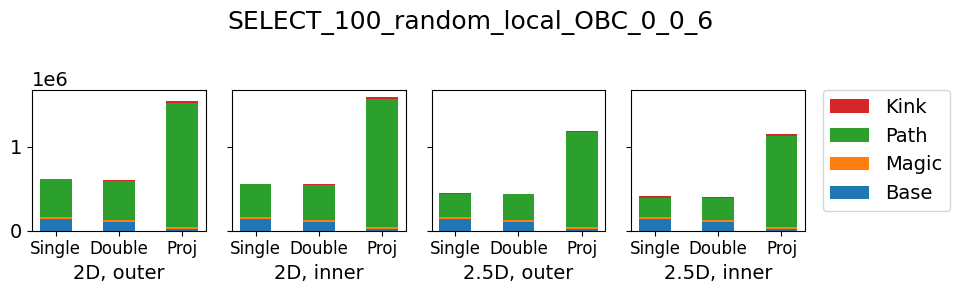

Kink 116249.0
Kink 147090.0
Kink 222191.0
Kink 516349.0


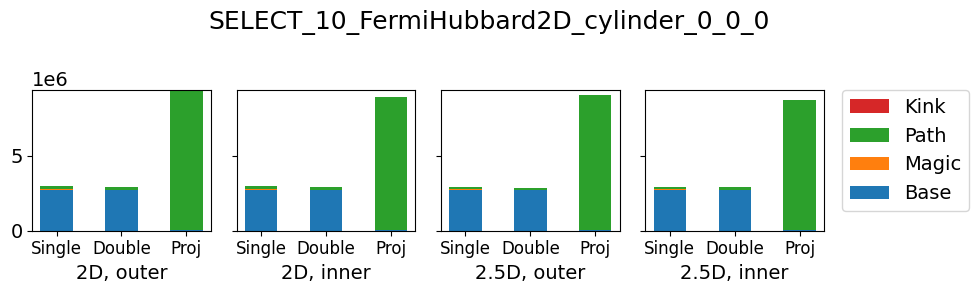

Kink 149071.0
Kink 152094.0
Kink 207432.0
Kink 132518.0


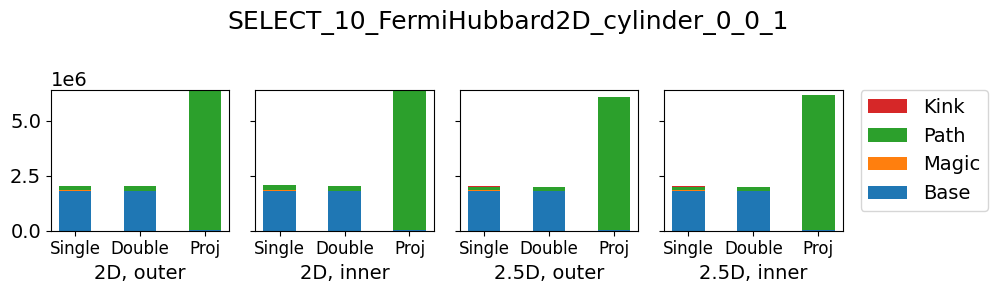

Kink 98203.0
Kink 205198.0
Kink 165993.0
Kink 324801.0


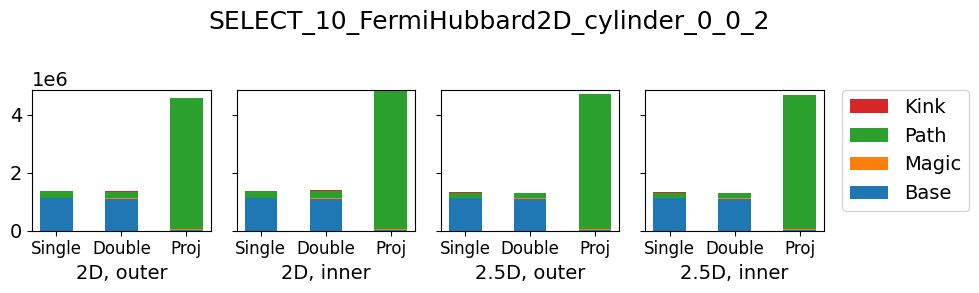

Kink 147537.0
Kink 40902.0
Kink 140406.0
Kink 117680.0


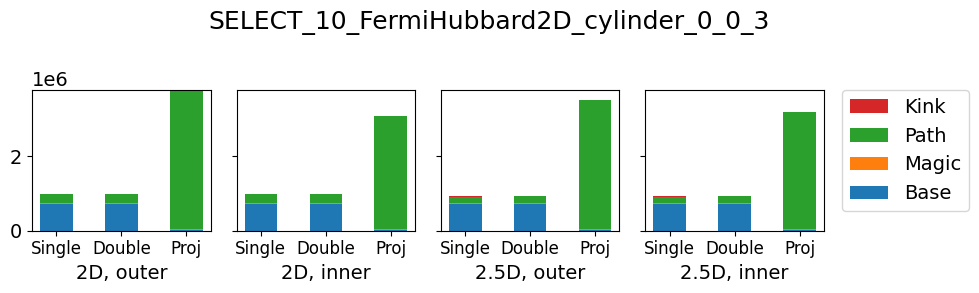

Kink 42609.0
Kink 101401.0
Kink 492.0
Kink 106204.0


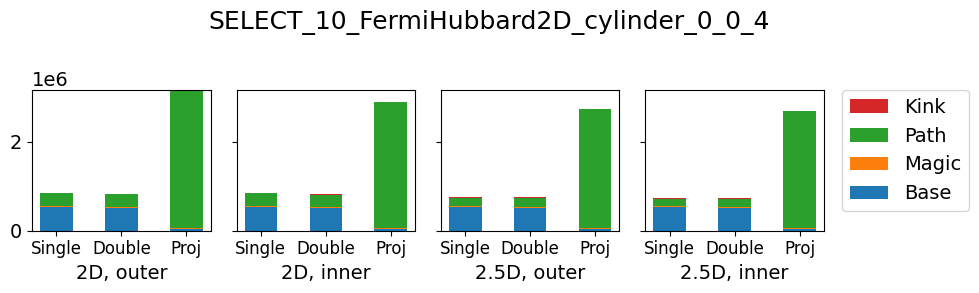

Kink 11105.0
Kink 48426.0
Kink 98827.0


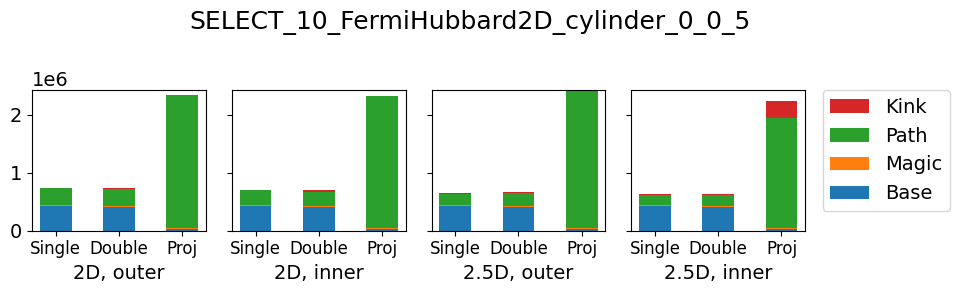

Kink 15873.0
Kink 4135.0


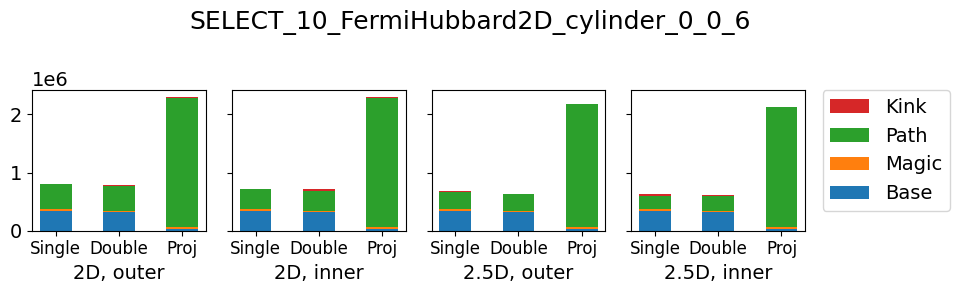

Kink 1418.0
Kink 62626.0
Kink 209962.0
Kink 58875.0


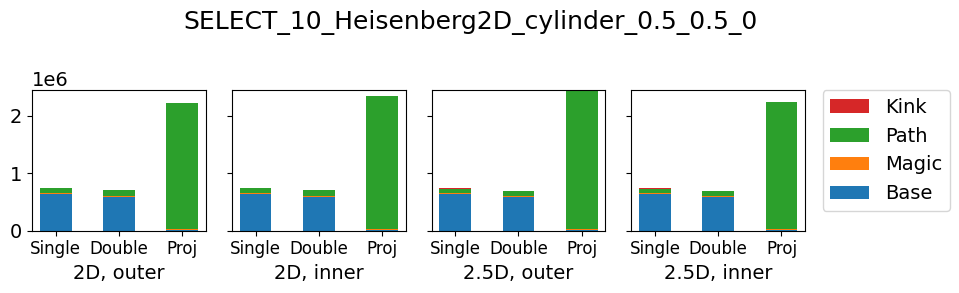

Kink 25069.0
Kink 54195.0
Kink 85964.0
Kink 62001.0


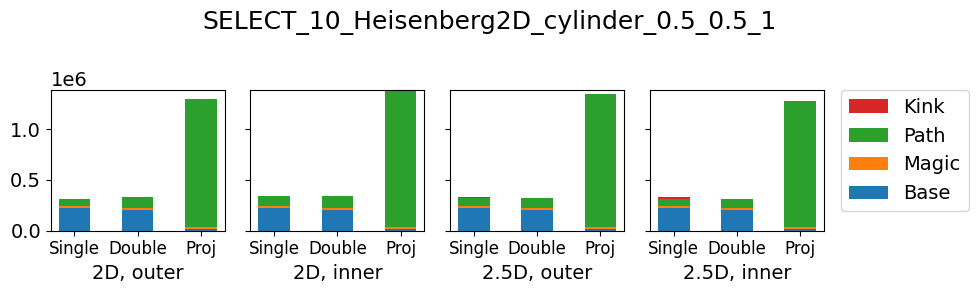

Kink 34657.0
Kink 40946.0
Kink 119026.0
Kink 13570.0


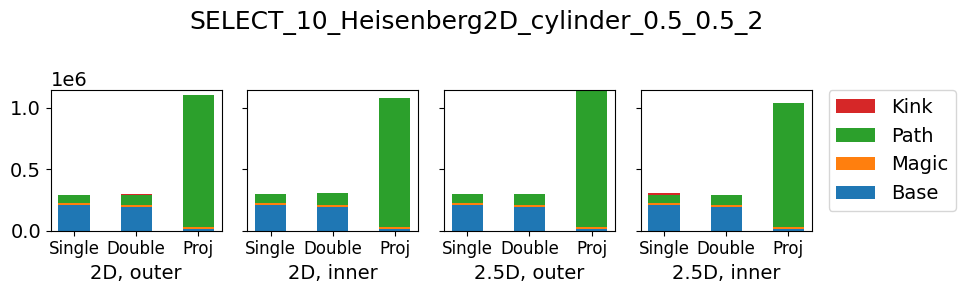

Kink 20970.0
Kink 25869.0
Kink 15860.0
Kink 21715.0


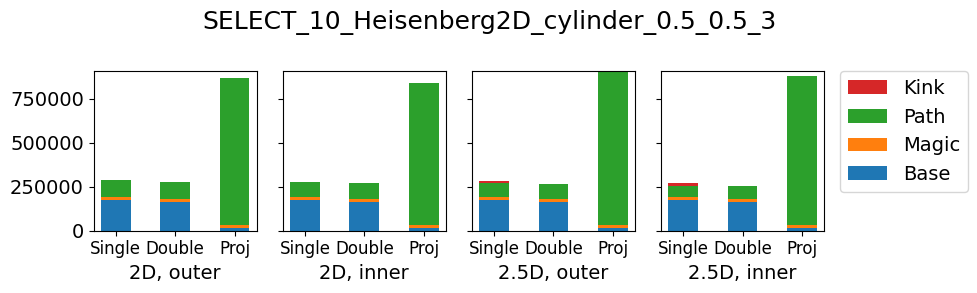

Kink 23123.0
Kink 17289.0
Kink 12113.0
Kink 15381.0


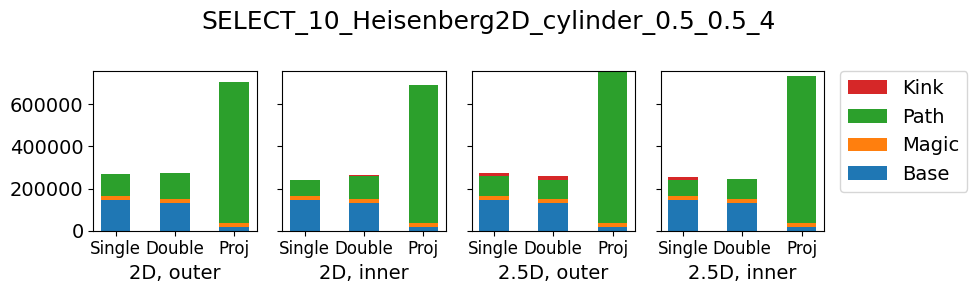

Kink 278.0
Kink 5540.0
Kink 5850.0


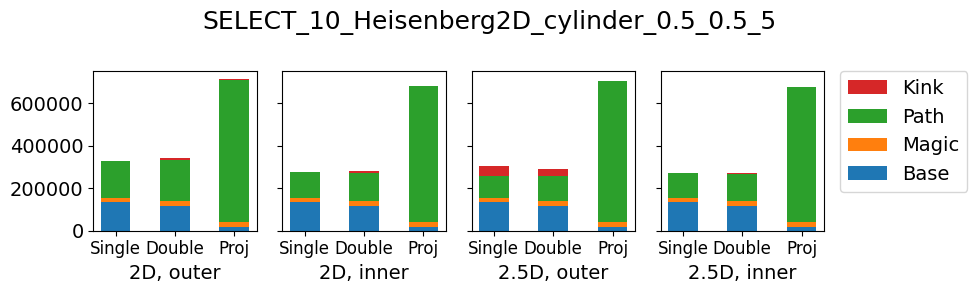

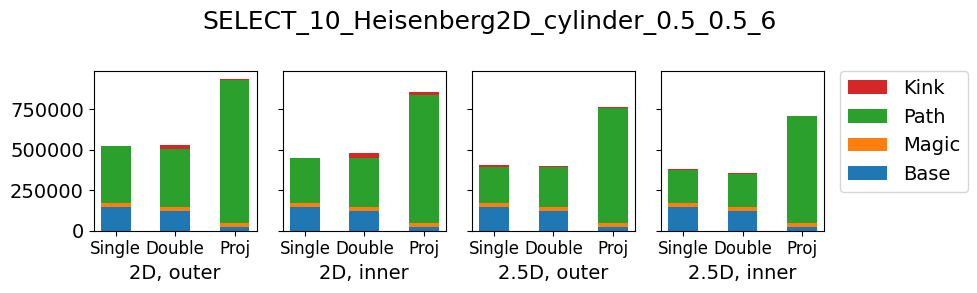

Kink 15863.0
Kink 9424.0
Kink 1254.0
Kink 7172.0


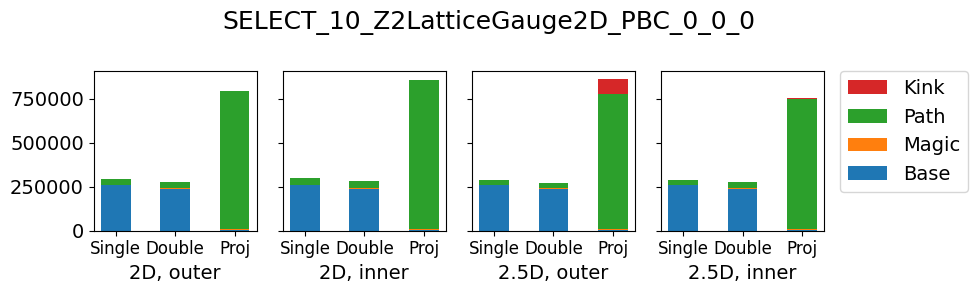

Kink 615.0
Kink 4597.0
Kink 2951.0
Kink 378.0


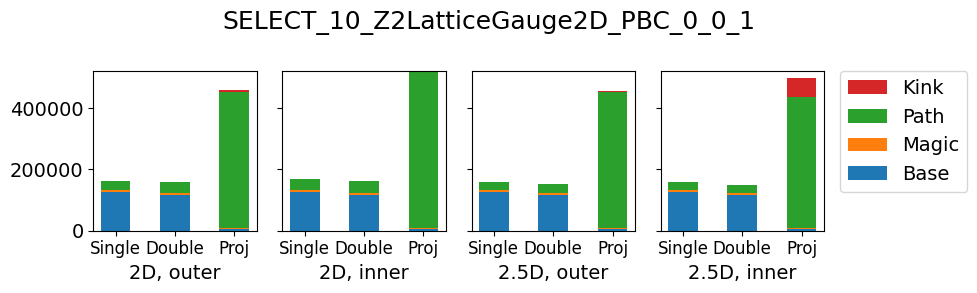

Kink 3089.0
Kink 1180.0
Kink 2884.0


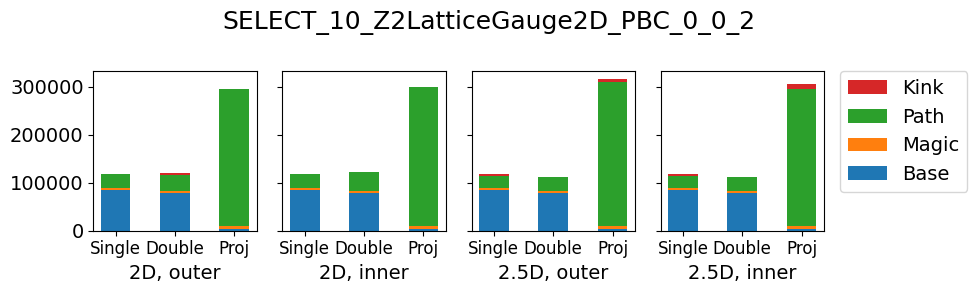

Kink 8292.0
Kink 7254.0
Kink 2139.0


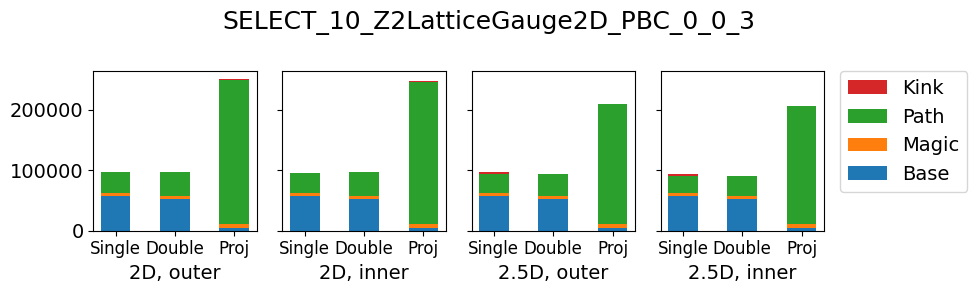

Kink 269.0
Kink 1306.0


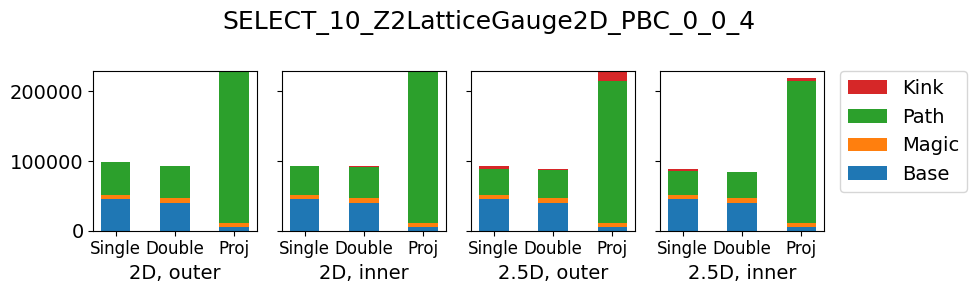

Kink 8174.0
Kink 7336.0
Kink 6270.0


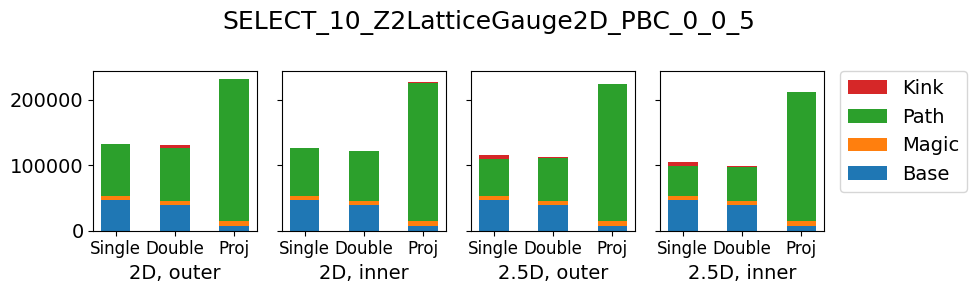

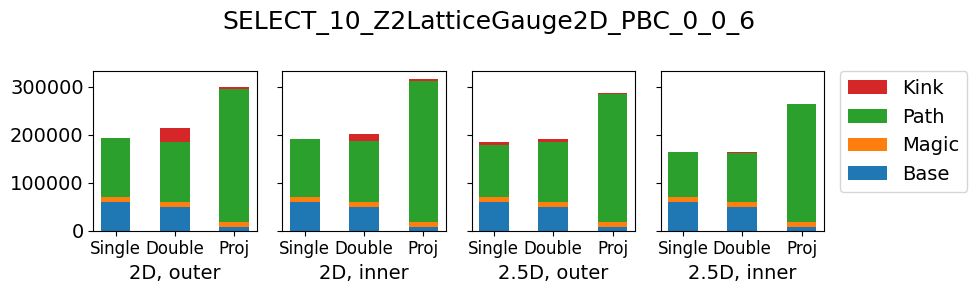

Kink 4726.0
Kink 3148.0
Kink 11596.0
Kink 13683.0


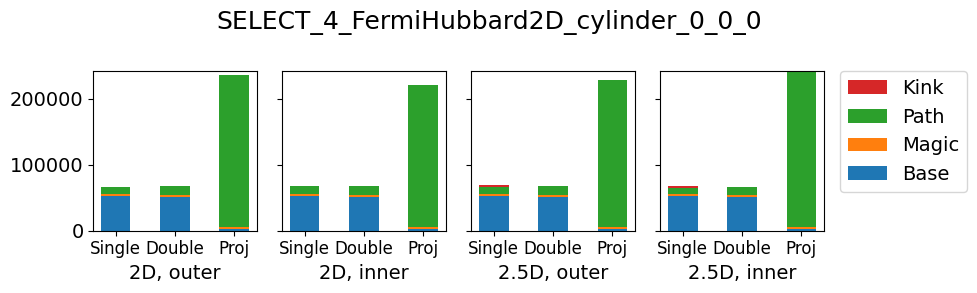

Kink 6324.0
Kink 6353.0
Kink 9642.0
Kink 3050.0


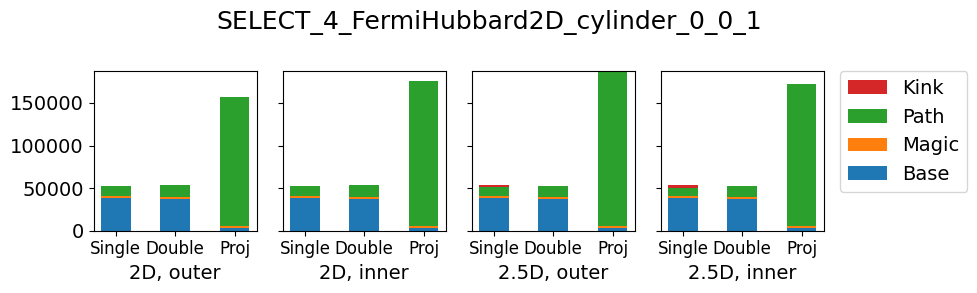

Kink 4660.0
Kink 4468.0
Kink 4017.0


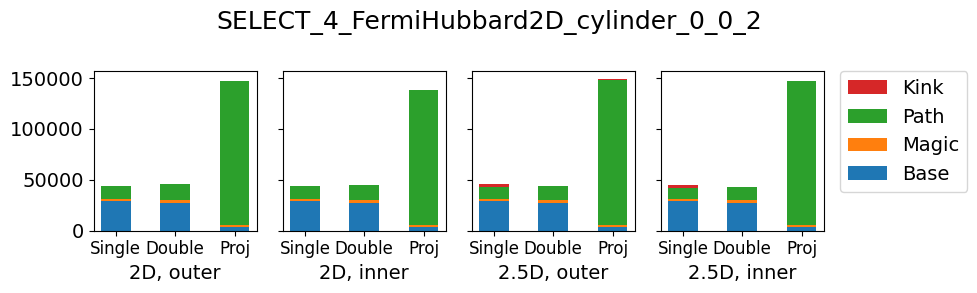

Kink 2158.0
Kink 1473.0
Kink 2017.0
Kink 2175.0


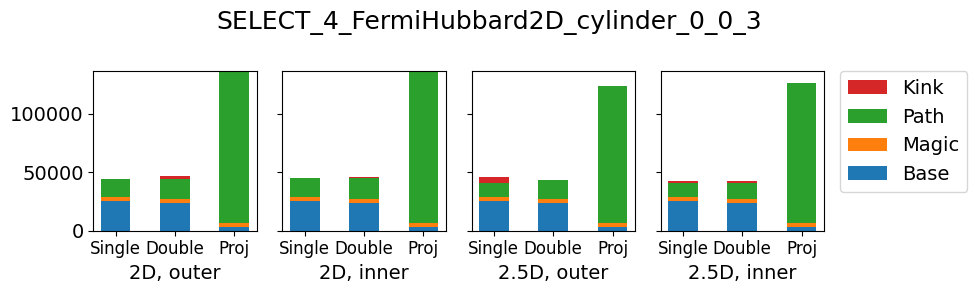

Kink 6537.0


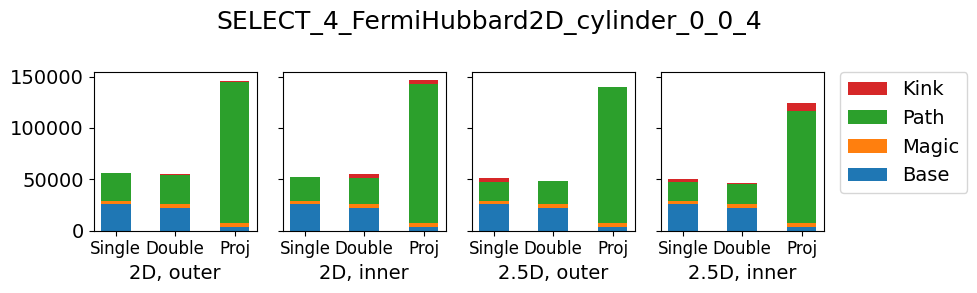

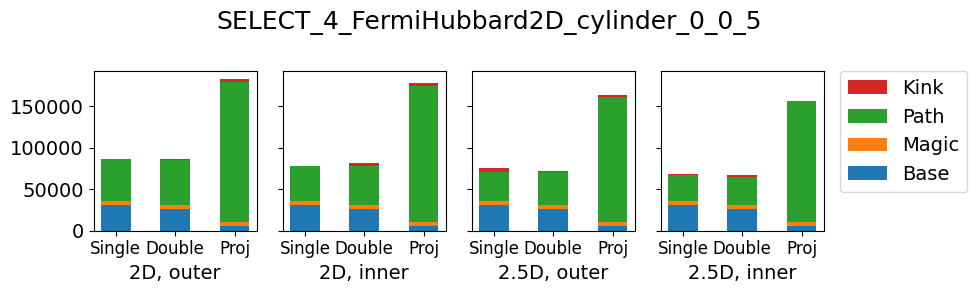

Kink 3062.0
Kink 1728.0


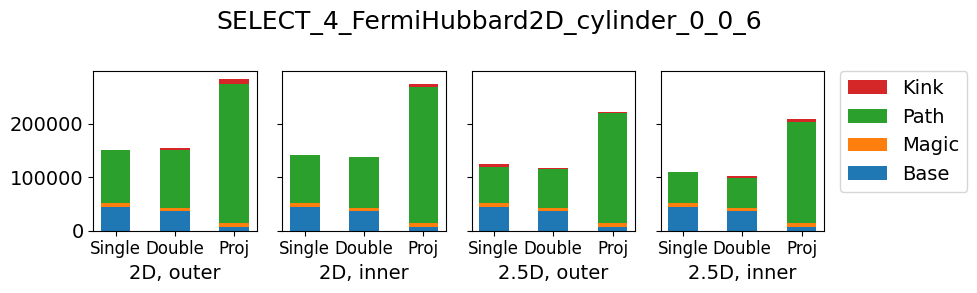

Kink 20874.0
Kink 13109.0
Kink 60999.0
Kink 46378.0


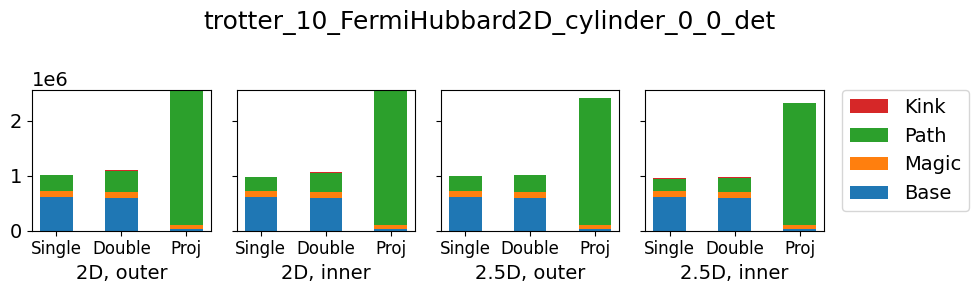

Kink 1069.0
Kink 30598.0
Kink 13342.0


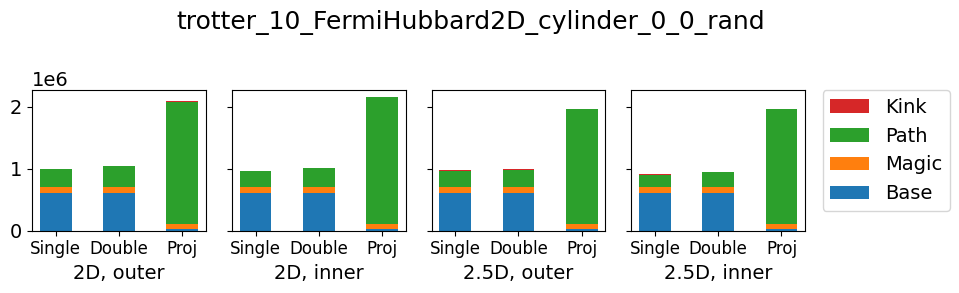

Kink 12458.0
Kink 25685.0
Kink 12567.0
Kink 22462.0


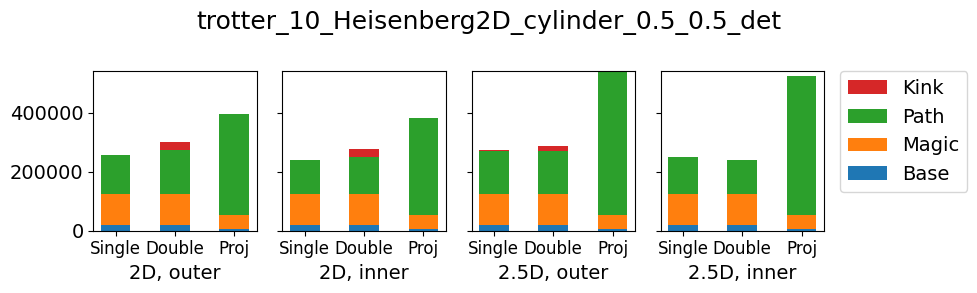

Kink 12345.0
Kink 21759.0
Kink 11333.0
Kink 24008.0


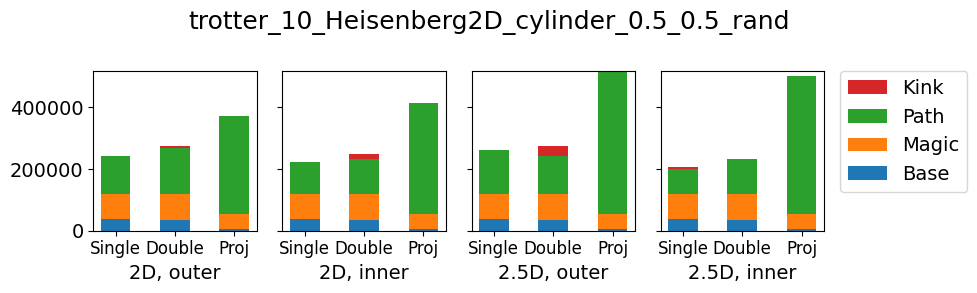

Kink 1847.0
Kink 878.0
Kink 2755.0
Kink 1056.0


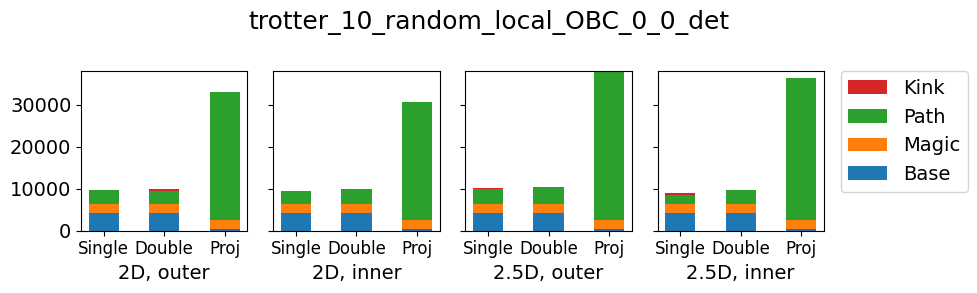

Kink 4434.0
Kink 404.0
Kink 2616.0
Kink 1338.0


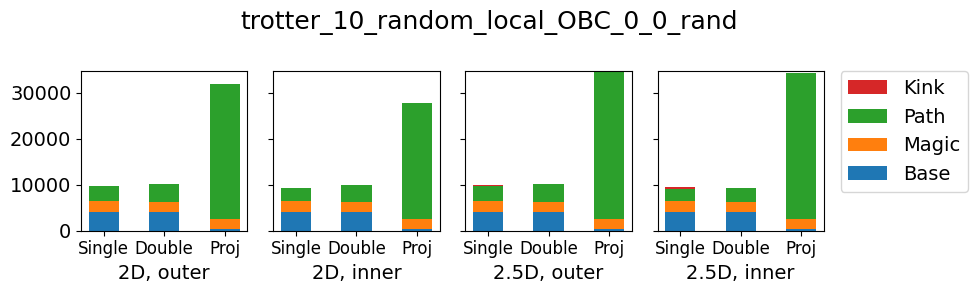

Kink 60575.0
Kink 164607.0
Kink 48330.0
Kink 115086.0


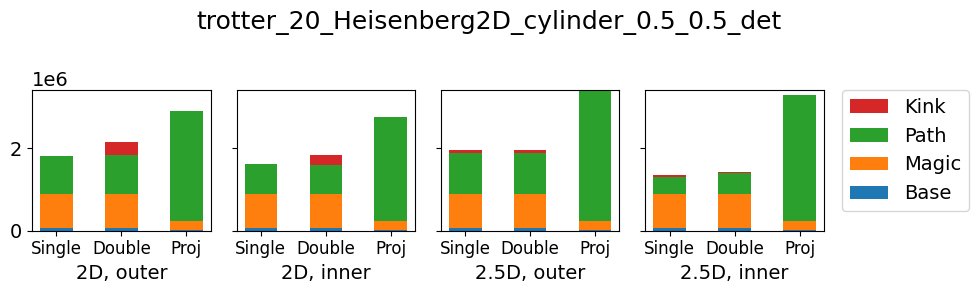

Kink 70485.0
Kink 155247.0
Kink 53423.0
Kink 97249.0


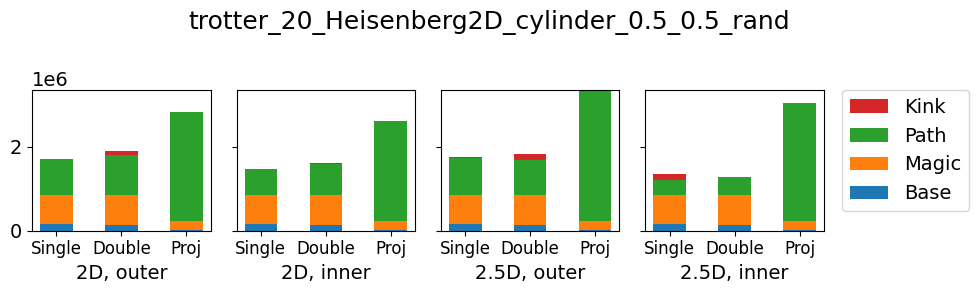

Kink 2980.0
Kink 1493.0
Kink 87.0
Kink 7068.0


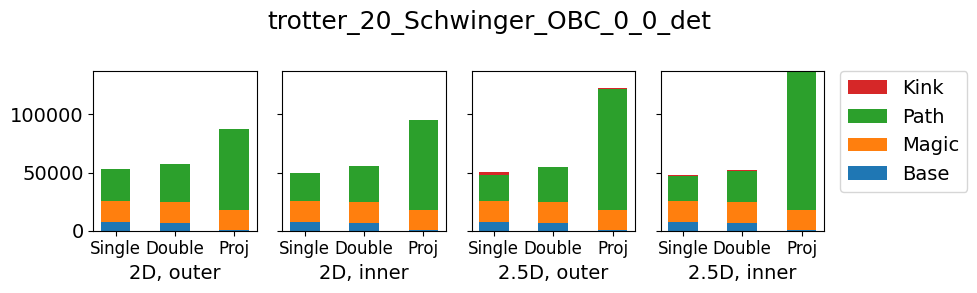

Kink 2094.0
Kink 287.0
Kink 2967.0
Kink 4205.0


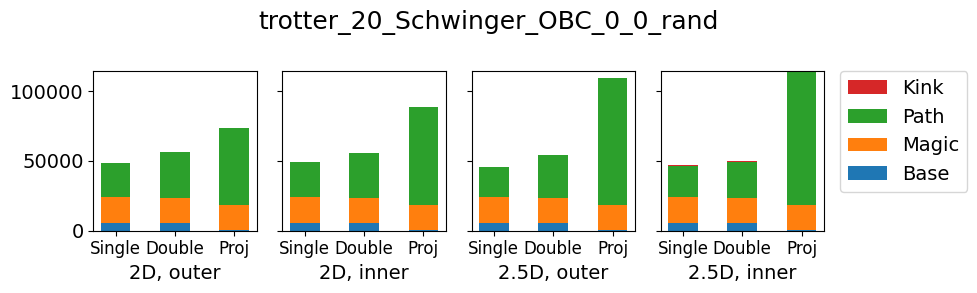

Kink 118041.0
Kink 396144.0
Kink 92226.0
Kink 321516.0


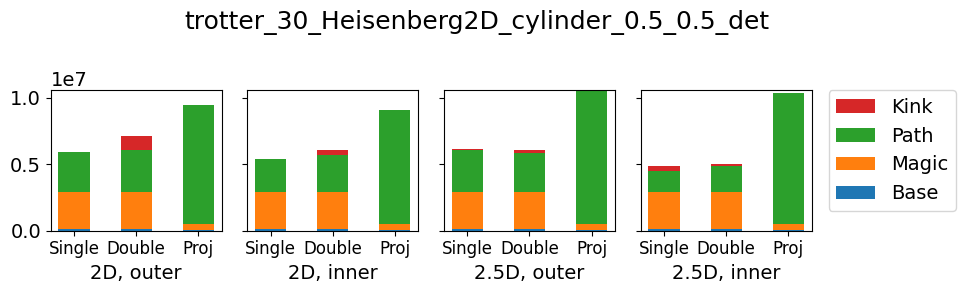

Kink 181263.0
Kink 260182.0
Kink 126156.0
Kink 214633.0


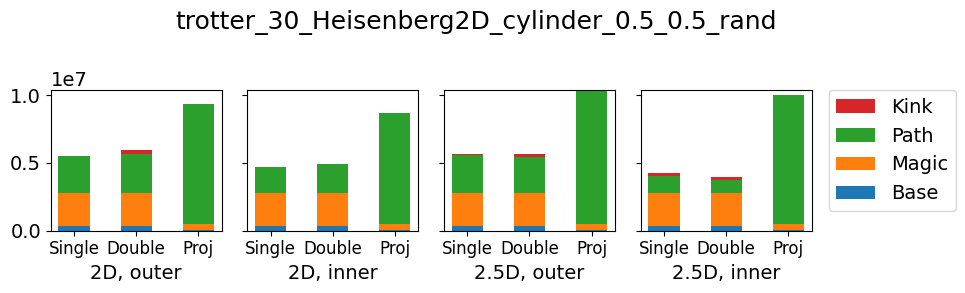

Kink 4610.0
Kink 6574.0
Kink 7477.0


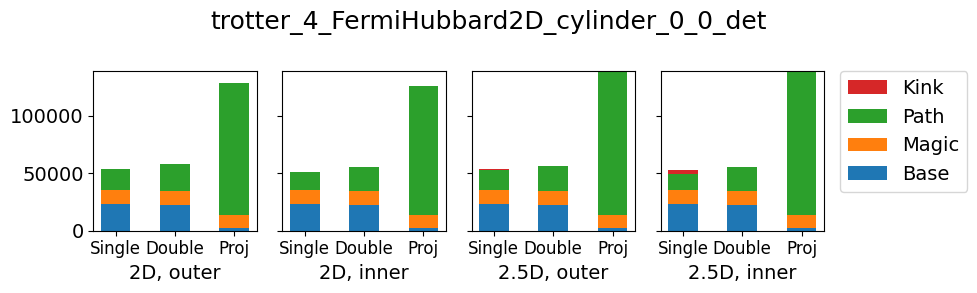

Kink 4625.0
Kink 3837.0
Kink 2451.0
Kink 2824.0


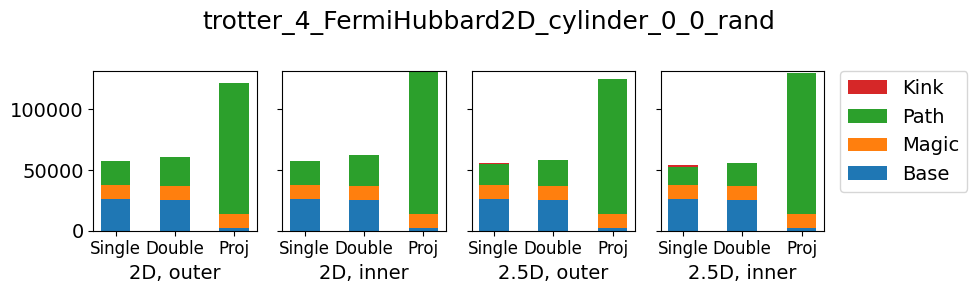

Kink 1132.0
Kink 1442.0
Kink 1426.0
Kink 2370.0


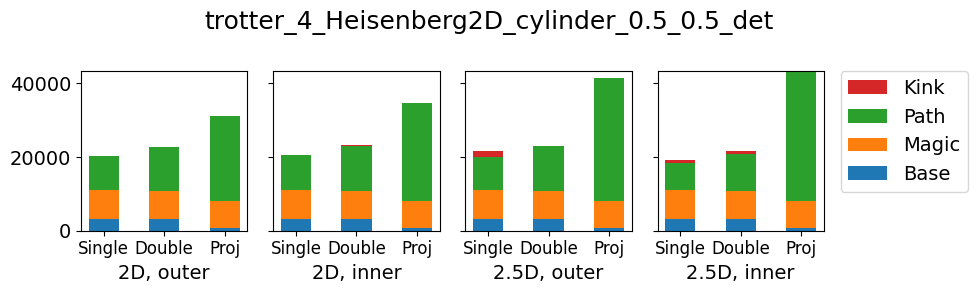

Kink 3387.0
Kink 1989.0
Kink 4678.0
Kink 1334.0


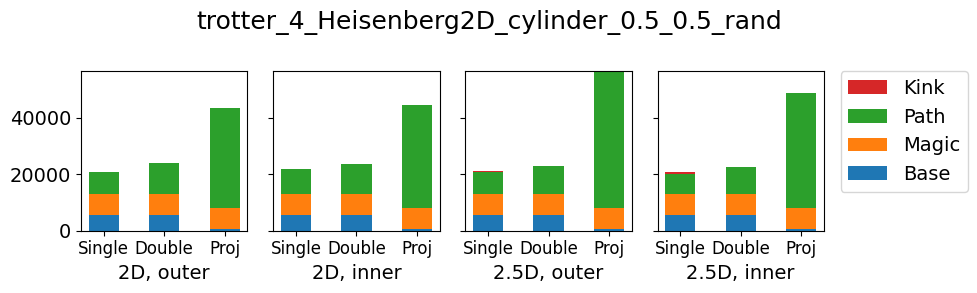

In [ ]:
def draw_circuit_volume():

    def draw(ax: Any, df_ax: pd.Series) -> None:
        bottom = np.zeros(len(routing_algos))
        for label_for_df, label_for_legend in breakdown.items():
            df_bd = df_ax[df_ax["routing_option"] == label_for_df].set_index(
                "routing_algo"
            )
            method_height = bottom.copy()
            for i, routing_algo in enumerate(routing_algos):
                if routing_algo in df_bd.index:
                    method_height[i] = df_bd["circuit volume"].at[routing_algo]
            if np.any(bottom > method_height):
                print(label_for_legend, np.max(bottom - method_height))
                method_height = np.maximum(method_height, bottom)
            ax.bar(
                routing_algos,
                method_height - bottom,
                0.5,
                label=label_for_legend,
                bottom=bottom,
            )
            ax.tick_params(axis="x", labelsize=12)
            bottom = method_height

    def plot_circuit_wise(
        circuit: str,
        df_circuit: pd.DataFrame,
        save: bool = False,
        save_dir: str = "../../fig/cbpi_stack",
    ) -> None:
        if save:
            os.makedirs(save_dir, exist_ok=True)

        fig, axes = plt.subplots(
            1,
            len(options),
            figsize=(2 * len(options) + 2, 3),
            sharex=True,
            sharey=True,
        )

        for ax, option in zip(axes, options):
            layer_count, factory = option
            draw(
                ax,
                df_circuit[
                    (df_circuit["layer count"] == layer_count)
                    & (df_circuit["factory"] == factory)
                ],
            )

        fig.suptitle(circuit.replace("result_", ""), fontsize=18)
        for j, option in enumerate(options):
            layer_count, factory = option
            dim = "2D" if layer_count == 1 else "2.5D"
            axes[j].set_xlabel(f"{dim}, {factory}")

        handles, labels = axes[-1].get_legend_handles_labels()
        axes[-1].legend(
            handles=handles[::-1],
            labels=labels[::-1],
            bbox_to_anchor=(1.1, 1),
            loc="upper left",
            borderaxespad=0,
        )

        plt.tight_layout()
        if save:
            figname = os.path.join(save_dir, circuit + ".png")
            plt.savefig(figname)
        plt.show()

    for circuit, df_circuit in sorted(df_best_sa.groupby("circuit")):
        plot_circuit_wise(circuit, df_circuit, False)
        # break


draw_circuit_volume()